# 📦 **SYNTHETIC BLOCK MODEL GENERATOR**

This notebook builds a **realistic, fully customisable 3D block model** for mining applications — simulating geological, spatial, geometallurgical, and economic behaviour observed in real-world deposits.

It is designed for **Mine-to-Mill analysis, visualisation, prototyping, and synthetic data generation**. Users have full control over orebody geometry, mineral and rock properties, economics, classification logic, and fault-based effects — all using modular, transparent code.

---

### 🎯 Key Objectives
* Generate realistic **3D orebody geometry** with domains (e.g. Core, Mid, Outer)
* Assign spatially continuous **grades, physical, and metallurgical attributes**
* Incorporate **economic logic** (prices, recoveries, units, exchange rates)
* Apply **Ore/Waste classification **using value-based cut-offs
* Simulate **fault zones** with enrichment/weakening effects
* Calculate **volume, tonnes, contained metal** and apply **SMU smoothing**
* Visualise in 2D (slices, cross sections, histograms) and full **3D with PyVista**
* Simulate **drillhole assays** and validate property correlations
* Export block model to **CSV, Parquet, JSON **for downstream tools


---

### 🧭 Notebook Structure

#### 🔧 1. User Parameters
* Configure block size, extent, mineral settings, domain geometry, fault logic
* Toggle optional features (e.g. property dependencies, SMU, drillholes)

#### 🏗️ 2. Block Model Generation
* Define orebody and fault zone geometry using Perlin noise
* Loop through 3D grid to assign properties to each block
* Apply inter-property dependency logic (e.g. UCS → Axb, RMR)

#### 🧮 3. Property Assignment & Viewer
* Assign mineral grades, geophysics, geomechanics, metallurgy
* Add processing tags (e.g. lithology, alteration, oxidation zone)
* Use interactive sliders to inspect slices by property and depth

#### 💾 4. Export Model
* Output to .csv, .parquet, .json

#### 🧱 5. Economic Calculations
* Compute block-level value per tonne for each mineral and total
* Classify blocks as Ore or Waste using configurable cut-offs

#### 📊 6. Geological Domains
* Assign each block to domains (Core, Inner, Outer, Background)
* View domain-filtered cross sections and bar charts
* Summarise domain-by-class statistics and value distributions

#### 🖼️ 7. Resource & Volume Estimation
* Calculate volume, tonnes, average grade, and contained metal
* Apply SMU smoothing to simulate operational selectivity loss
* Add unique block_id for traceability
* Run QA checks: histograms, correlations, drillhole assays
* Interactive 2D slice viewer with fault/domain overlays
* Full 3D block rendering using PyVista (point cloud, voxel, slice)
* Simulated drillholes with vertical assay plots (multi-metal)

#### 💾 8. Export Final Model
* Output to .csv, .parquet, .json
* Optional export of drillhole assays

---

#### ✅ Why Use This?

This tool is useful for:
* Prototyping and validation of new block model logic
* Demonstration of spatial modelling principles
* Economic analysis and cut-off sensitivity testing
* Visual QA/QC for fault and domain logic
* Synthetic data creation for machine learning or scheduling workflows

---

## ⚙️ **Step 1: Define User Parameters**

This section contains all user-configurable inputs. These parameters define the orebody geometry, block model generation rules, and downstream geological and economic properties.

Each section is modular, allowing easy adjustment or extension for more complex simulations.

---

#### 📐 **Model Geometry**
- The user defines the **orebody extent**, and the model automatically expands this by a configurable margin (e.g. 30%) to allow for realistic mine design and pit shell development.
- The **model extent** is derived based on the orebody and margin.
- Block size and model origin are also defined here.

#### 🪨 **Mineral Properties**
- Define key economic minerals (e.g. Au, Cu) using Perlin noise
- Configure grade ranges, smoothness, and spatial seed

#### 🧲 **Geophysical Data**
- Simulate density, magnetics, resistivity, gamma
- Used for process modelling or geological characterisation

#### 🧱 **Geomechanical Properties**
- UCS and RMR for fragmentation or slope design
- Can be generated independently or linked to other attributes

#### ⚙️ **Metallurgical Properties**
- Axb, BWi, DWi, and grindability
- Used to simulate hardness and plant throughput

#### ⚗️ **Processing Indices**
- Floatability and reagent demand for downstream modelling
- Optional but useful for circuit simulation

#### 🧪 **Inter-Property Dependencies**
- Enforce geological realism by linking parameters
- Examples: $RMR = 0.3 × UCS + 40$ or $grindability = f(Axb, BWi)$

#### 📊 **Property Display Settings**
- Set colormaps, value ranges, and plot labels for visualisation

#### 💰 **Economic Parameters**
- Metal pricing, recovery factors, currency exchange
- Used to calculate block-level economic value

#### 📍 **Geological Domains**
- Define zones like Orebody, Core using shapes like cylinders or ellipsoids
- These control filtering, visualisation, and classification

#### 🎨 **Domain Colours**
- Assign colours to different domains for easier visual interpretation

#### 🧬 **Categorical Attributes (Optional)**
- Stratigraphy, lithology, processing route, oxidation zone
- Useful for classification and selectivity analysis

#### 🛠️ **Feature Toggles**
- Enable/disable property categories and dependency logic

#### 🕳️ **Drillhole Simulation**
- Define number of simulated drillholes
- Useful for testing sampling and interpolation logic

## 🧱 Typical Porphyry Geometry

|- **Characteristic	Range** |- **Style** |
|*-- Shape |*-- Steeply plunging, broadly cylindrical to ellipsoidal |
Plunge				~45°–80°, often along structural trends
Vertical Extent		500 – 1500 m+
Horizontal Extent	300 – 800 m diameter
Zoning				Strong vertical zonation (e.g., Cu-rich core, Au halo)
Faulting			Often crosscut by post-mineral or syn-mineral faults

In [71]:
# ======================================================================
# 📦 STEP 1: DEFINE USER PARAMETERS ###
# ======================================================================
import numpy as np

# ======================================================================
# 📋 GLOBAL TOGGLES FOR VISUALISATION & PERFORMANCE
# ======================================================================

preview_mode = True          					# If True, downsample heavy plots and visuals
enable_orebody_fault_zone_plot = True        	# Toggle for PyVista 3D view (Step 2.2)
enable_orebody_fault_overlay = False  			# Toggle fault overlay in 3D view (Step 2.2)
enable_diagnostics = True    					# Toggle for all Step 2.3 plots

# Sampling limits (used when preview_mode = True)
max_pairplot_rows = 3000
max_crossplot_rows = 5000
max_3d_points = 50000

inc_multiplier = False  						# If True, use multiplier to calculate max for color scale
cuttoff_au_visuals = 0.3  						# Cutoff grade (g/t) used for visualisation
cuttoff_cu_visuals = 0.1  						# Cutoff grade (%) used for visualisation

mining_method = "open_pit"  					# Options are "open_pit" or "underground"

# ==============================================================================
# MODEL DIMENSIONS & GEOMETRY
# ==============================================================================

# --- Define topographic & weathering reference for model alignment ---
topo_base_elevation = 200                			# Mean elevation in metres
topo_variation_amplitude = 30           			# Elevation range above/below mean
topo_noise_scale = 0.02                 			# Controls undulation smoothness
topo_seed = 999                         			# For reproducibility

oxidation_oxide_depth = 40              			# Thickness of oxide zone (m)
oxidation_transition_depth = 20         			# Thickness of transition zone (m)

lowest_surface_elevation = topo_base_elevation - topo_variation_amplitude  
highest_surface_elevation = topo_base_elevation + topo_variation_amplitude

orebody_height = 800				 				# Height of orebody (m)

# --- Set orebody top and bottom based on mining method ---
if mining_method == "open_pit":
	orebody_top = topo_base_elevation - 10    		# Start just below lowest surface
	orebody_bottom = orebody_top - orebody_height   # Simulate depth of orebody
elif mining_method == "underground":
	orebody_top = lowest_surface_elevation - 50   	# Deeper to simulate UG access
	orebody_bottom = orebody_top - orebody_height   # Simulate depth of orebody
else:
	raise ValueError(f"Unknown mining_method: {mining_method}")

# --- Compute center and half-height for ellipsoid ---
orebody_center_z = (orebody_top + orebody_bottom) / 2
orebody_half_height = orebody_height / 2

orebody_center = (2000, 1000, orebody_center_z)
orebody_semi_axes = (400, 300, 400)  	# a, b, c in metres
# orebody_semi_axes = (1000, 600, orebody_half_height)  	# a, b, c in metres

include_margin_zone = True
orebody_margin_factor = 1.15                     # Expand model to % of orebody dimensions

# --- Compute full model extent based on orebody + margin ---
buffer_factor = orebody_margin_factor if include_margin_zone else 1.0

x_min = orebody_center[0] - orebody_semi_axes[0] * buffer_factor
x_max = orebody_center[0] + orebody_semi_axes[0] * buffer_factor
y_min = orebody_center[1] - orebody_semi_axes[1] * buffer_factor
y_max = orebody_center[1] + orebody_semi_axes[1] * buffer_factor
z_min = orebody_center[2] - orebody_semi_axes[2] * buffer_factor
z_max = orebody_center[2] + orebody_semi_axes[2] * buffer_factor

model_origin = (x_min, y_min, z_min)
model_extent = (x_max - x_min, y_max - y_min, z_max - z_min)

# --- Model Geometry ---
model_dimensions = {
	"origin": model_origin,
	"extent": model_extent,
	"block_size": (25, 25, 10),
}

extent = model_dimensions["extent"]				# For referencing in domain setup

# ==============================================================================
# DOMAIN DEFINITIONS (Spatial + Concentric Zones)
# ==============================================================================

domain_definitions = {
	"Orebody": {
		"shape": "plunging_ellipsoid",
		"center": orebody_center,
		"semi_axes": orebody_semi_axes,      	# a, b, c in metres
		"plunge_deg": 60,               		# plunge direction
		"azimuth_deg": 45,             	 		# SW-NE plunge direction
		"depth_range": (orebody_bottom, orebody_top),	# Z range in metres
	},
	"Core": {
		"shape": "ellipsoid",
		"center": orebody_center,
		"semi_axes": (200, 200, 100),
		"depth_range": (
			orebody_center_z - 50,
			orebody_center_z + 50
		)
	},
	"Inner": {
		"shape": "ellipsoid",
		"center": orebody_center,
		"semi_axes": (400, 300, 150),
		"depth_range": (
			orebody_center_z - 75,
			orebody_center_z + 75
		)
	},
	"Mid": {
		"shape": "ellipsoid",
		"center": orebody_center,
		"semi_axes": (700, 450, 250),
		"depth_range": (
			orebody_center_z - 125,
			orebody_center_z + 125
		)
	},
	"Outer": {
		"shape": "ellipsoid",
		"center": orebody_center,
		"semi_axes": orebody_semi_axes,
		"depth_range": (
			orebody_bottom,
			orebody_top
		)
	}
}

domain_colours = {
	"Deep Core": "red",
	"Core": "blue",
	"Inner": "purple",
	"Mid": "orange",
	"Outer": "yellow",
	"Background": "grey",
	"Zone" : "Set1"
}

# ==============================================================================
# GEOLOGICAL CATEGORISATION LOGIC
# ==============================================================================

# --- Grain Size Thresholds (radial distance from center) ---
grain_size_thresholds = {
	"Fine": 100,
	"Medium": 200
}

# --- Stratigraphy boundary (fraction of X extent) ---
stratigraphy_boundary_fraction = 0.3  # 30% of model width in X


# --- Alteration Perlin noise parameters ---
alteration_noise_params = {
	"scale": 0.05,
	"seed": 110
}

# ==============================================================================
# CONCENTRIC ZONE PARAMETERS
# ==============================================================================

zone_grade_multipliers = {
    1: {"Au": 0.1, "Cu": 0.1},
    2: {"Au": 0.4, "Cu": 0.3},
    3: {"Au": 1.0, "Cu": 1.0},
    4: {"Au": 1.4, "Cu": 1.2},
    5: {"Au": 2.0, "Cu": 1.6}
}

processing_route_by_zone = {
    "Outer": "Bioleach",
    "Mid": "Float",
    "Inner": "Float",
    "Core": "Leach",
    "Deep Core": "Leach"
}

lithology_by_zone = {
	"Outer": "POR",   		# Porphyry
	"Mid": "BX",    		# Breccia
	"Inner": "SH",    		# Sedimentary Host
	"Core": "DIO",   		# Diorite
	"Deep Core": "GRAN"   	# Granite / background
}

# ==============================================================================
# MINERAL GRADES
# ==============================================================================

minerals = {
	"Au": {
		"grade_range": (0.3, 3.5),
		"noise_scale": 0.05,
		"octaves": 2,
		"seed": 42
	},
	"Cu": {
		"grade_range": (0.1, 1.2),
		"noise_scale": 0.04,
		"octaves": 3,
		"seed": 24
	}
}

background_grade_suppression_factor = 0.05  # Reduce to 5% of original grade outside orebody

primary_mineral = "Au_grade"
primary_mineral_unit = "g/t"
secondary_mineral = "Cu_grade"
secondary_mineral_unit = "%"

# ==============================================================================
# PROPERTY DEPENDENCIES
# ==============================================================================

enable_property_dependencies = True

# Relationships between geomechanical/metallurgical properties
# e.g. RMR = a × UCS + b + ε, where ε ~ N(0, σ²)
property_dependencies = {
	"RMR_from_UCS": {"enabled": True, "a": 0.3, "b": 40, "noise_std": 2.0},
	"Axb_from_UCS": {"enabled": True, "a": -0.4, "b": 120, "noise_std": 5.0},
	"BWi_from_UCS": {"enabled": True, "a": 0.04, "b": 10, "noise_std": 0.5},
	"DWi_from_BWi": {"enabled": True, "a": 0.5, "b": 4, "noise_std": 0.2},
	"grindability_from_Axb_BWi": {
		"enabled": True,
		"formula": lambda axb, bwi: np.clip(
			(axb / 120) * (1 - (bwi - 8)/12) + np.random.normal(0, 0.05), 0, 1
			)
	}
}

# Clipping ranges to prevent extreme values
property_dependency_clipping = {
	"RMR": (40, 100),
	"Axb": (25, 130),
	"BWi": (7, 21),  
	"DWi": (2, 15),  
	"grindability": (0.05, 0.95)  # Better than (0, 1) to reduce clipping at bounds
}

# ==============================================================================
# ECONOMICS
# ==============================================================================

target_currency = "AUD"

exchange_rates = {
	"AUD": 1.0,
	"USD": 1 / 1.5,
	"CAD": 0.91,
}

economic_data = {
	"Au": {
		"price_per_oz_usd": 1950,
		"recovery": 0.92,
		"unit": "oz"
	},
	"Cu": {
		"price_per_lb_usd": 4.0,
		"recovery": 0.88,
		"unit": "%"
	}
}

# Ore/waste cut-off threshold used for:
# - Classifying blocks as Ore vs Waste (e.g., in block_model_df["class"])
# - Applying SMU smoothing logic (Step 7.4)
# - Filtering economic blocks for pit shell generation and scheduling (Step 2)
value_cutoff = 150  # in AUD/tonne


# ==============================================================================
# FAULT ZONE
# ==============================================================================

enable_fault_zone = True

fault_planes = [
	{
		"name": "Fault_A",
		"dip_deg": 70,
		"azimuth_deg": 45,
		"origin": (
			orebody_center[0],
			orebody_center[1],
			orebody_center[2] + 20  # Vertical offset from main orebody
		),
		"thickness": 20,
		"roughness": 4.0,
		"curvature_amplitude": 15.0,
		"curvature_scale": 200.0,
		"thickness_variation_scale": 150.0,
		"offset_y_threshold": 1000,
		"offset_x_shift": 60.0,
		"halo_extent": 4.0
	},
	{
		"name": "Fault_B",
		"dip_deg": 60,
		"azimuth_deg": 110,
		"origin": (
            orebody_center[0] - 200,  # Slight X/Y offset
            orebody_center[1] + 150,
            orebody_center[2]
        ),
		"thickness": 15,
		"roughness": 3.0,
		"curvature_amplitude": 10.0,
		"curvature_scale": 180.0,
		"thickness_variation_scale": 120.0,
		"offset_y_threshold": None,
		"offset_x_shift": 0.0,
		"halo_extent": 3.0
	}
]


fault_grade_multiplier = {
	"Au": 1.5,  									# Enrichment factor for Au
	"Cu": 1.2   									# Enrichment for Cu
}

fault_property_multiplier = {
	"UCS": 0.7,
	"RMR": 0.85,
	"Axb": 1.2,
	"BWi": 0.9,
	"DWi": 0.9,
	"grindability": 1.1
}


# ==============================================================================
# ADVANCED PROPERTIES
# ==============================================================================

enable_geophysical_properties = True
enable_geomechanical_properties = True
enable_metallurgical_properties = True
enable_processing_indices = True
enable_categorical_attributes = True

geophysical_data = {
	"density": {"range": (2.4, 3.0), "noise_scale": 0.03, "octaves": 1, "seed": 99}
}

if enable_geophysical_properties:
	geophysical_data.update({
		"mag_sus": {"range": (0.001, 0.1), "noise_scale": 0.03, "octaves": 1, "seed": 13},
		"resistivity": {"range": (100, 1000), "noise_scale": 0.02, "octaves": 2, "seed": 14},
		"gamma": {"range": (0, 200), "noise_scale": 0.02, "octaves": 2, "seed": 15}
	})

if enable_geomechanical_properties:
	geomechanical_data = {
		"UCS": {"range": (20, 200), "noise_scale": 0.03, "octaves": 1, "seed": 16},
		"RMR": {"range": (30, 80), "noise_scale": 0.03, "octaves": 1, "seed": 17}
	}

if enable_metallurgical_properties:
	met_data = {
		"Axb": {"range": (30, 120), "noise_scale": 0.04, "octaves": 1, "seed": 18},
		"BWi": {"range": (8, 20), "noise_scale": 0.04, "octaves": 1, "seed": 19},
		"DWi": {"range": (3, 12), "noise_scale": 0.04, "octaves": 1, "seed": 20},
		"grindability": {"range": (0, 1), "noise_scale": 0.04, "octaves": 1, "seed": 21}
	}

if enable_processing_indices:
	processing_indices = {
		"floatability_index": {"range": (0.0, 1.0), "noise_scale": 0.03, "octaves": 1, "seed": 22},
		"reagent_demand": {"range": (0, 100), "noise_scale": 0.03, "octaves": 1, "seed": 23}
	}

if enable_categorical_attributes:
	processing_categories = {
		"oxidation_zone": ["Fresh", "Transition", "Oxide"],
		"processing_route": ["Float", "Leach", "Bioleach"]
	}
	geological_categories = {
		"lith_code": ["DIO", "SH", "GRAN", "OX"],
		"stratigraphy": ["Fm_A", "Member_B"],
		"alteration": ["Sericite", "Chlorite"],
		"grain_size": ["Fine", "Medium", "Coarse"]
	}

# ==============================================================================
# DRILLHOLE SIMULATION
# ==============================================================================

drillhole_parameters = {
	"n_holes": 10,
	"random_seed": 10
}

# ==============================================================================
# VISUALISATION
# ==============================================================================

property_display_ranges = {
	"Au_grade": (0, 3.5),
	"Cu_grade": (0, 1.2),
	"density": (2.4, 3.0),
	"value_per_tonne": (0, 300),
	"UCS": (30, 200),
	"Axb": (30, 120),
	"BWi": (8, 20),
	"DWi": (9, 15),
	"grindability": (0.0, 0.8),
	"floatability_index": (0.1, 0.9),
	"reagent_demand_index": (20, 80)
}

property_colormaps = {
	"Au_grade": "plasma",
	"Cu_grade": "viridis",
	"density": "cividis",
	"value_per_tonne": "inferno",
	"value_Au_per_tonne": "plasma",
	"value_Cu_per_tonne": "viridis",
	"class": "Set1",
	"UCS": "coolwarm",
	"Axb": "magma",
	"BWi": "magma",
	"floatability_index": "YlGnBu",
	"reagent_demand_index": "OrRd"
}

property_labels = {
	"Au_grade": "Au Grade (g/t)",
	"Cu_grade": "Cu Grade (%)",
	"density": "Density (g/cm³)",
	"value_per_tonne": "Value (AUD/t)",
	"value_Au_per_tonne": "Au Value (AUD/t)",
	"value_Cu_per_tonne": "Cu Value (AUD/t)",
	"class": "Classification",
	"UCS": "Unconfined Comp. Strength (MPa)",
	"Axb": "A×b Index",
	"BWi": "Bond Work Index (kWh/t)",
	"floatability_index": "Floatability Index",
	"reagent_demand_index": "Reagent Demand Index"
}

axis_adj = (100, 100, 50)  # Adjust axis limits for better visibility

# ==============================================================================
# OTHER
# ==============================================================================

# --- Unit conversion constants ---
OZ_TO_GRAMS = 31.1035    # 1 troy ounce = 31.1035 grams
LB_TO_KG = 0.453592       # 1 pound = 0.453592 kilograms

## 🧱 **Step 2: Generate Synthetic Block Model**
This step builds the full 3D synthetic block model using user-defined geological, geophysical, and economic rules. The model mimics real-world spatial structures like orebodies, faults, and alteration zones — and is fully customisable.

---

#### 🔧 **What Happens in Step 2:**
* Define domain and fault geometry logic
* Loop through a 3D grid to generate block attributes (grades, density, UCS, etc.)
* Apply spatial masking (e.g. orebody-only, margin zones, fault core/halo)
* Add noise and dependencies to simulate realistic geological variability
* Enable 3D and 2D visual validation tools
* Optionally load or save to Parquet for fast access

---

#### ✅ **Features Include:**
* Support for multiple minerals with independent control
* Domain-aware lithology and processing tags
* Fault-plane aware enrichment and weakening logic
* 2D and 3D visualisation of zones, fault volumes, and attributes
* Dependency rules like UCS → RMR, UCS → Axb/BWi, Axb/BWi → Grindability

---

### 🧰 **Step 2.1: Define Helper Functions**
This step sets up the key utility functions used across the notebook for spatial filtering, domain logic, fault detection, and interactive plotting.

---
#### 🔑 **Core Functions:**
* `is_in_domain(...)` – Checks if a block is inside a domain shape (e.g. cylinder, ellipsoid, plunging ellipsoid).
* `compute_fault_distance(...)` – Calculates distance from a block to a fault plane, with curvature, offset, and roughness.
* `is_in_fault_zone(...)` – Returns `True` if a block lies within the fault’s core zone.
* `fault_membership_category(...)` – Classifies blocks as `core`, `halo`, or `none`.
* `get_colorbar_limits(...)` – Sets colourbar ranges for plotting grade values.
* `make_axis_slider(...)` – Builds axis-based interactive sliders for property viewers.
* `get_valid_slice_positions(...)` – Ensures cross-sections have valid variation in the slicing axis.

These utilities are essential for enabling spatial logic and clean, responsive visualisations later in the notebook.

In [72]:
# ======================================================================
# 📦 STEP 2.1: DEFINE HELPER FUNCTIONS USED THROUGHOUT THE NOTEBOOK ###
# ======================================================================

import pandas as pd
from noise import pnoise3
import ipywidgets as widgets

# --- 1. Helper function to check spatial domain membership ---
def is_in_domain(row, params):
    shape = params["shape"]
    cx, cy, cz = params["center"]
    z_min, z_max = params.get("depth_range", (float("-inf"), float("inf")))

    dx = row["x"] - cx
    dy = row["y"] - cy
    dz = row["z"] - cz

    if not (z_min <= row["z"] <= z_max):
        return False

    if shape == "plunging_ellipsoid":
        a, b, c = params["semi_axes"]
        plunge_deg = params["plunge_deg"]
        azimuth_deg = params["azimuth_deg"]

        # Direction cosines
        plunge_rad = np.radians(plunge_deg)
        azimuth_rad = np.radians(azimuth_deg)
        ux = np.cos(plunge_rad) * np.cos(azimuth_rad)
        uy = np.cos(plunge_rad) * np.sin(azimuth_rad)
        uz = np.sin(plunge_rad)

        # Vector to block
        dx = row["x"] - cx
        dy = row["y"] - cy
        dz = row["z"] - cz

        # Depth-based taper
        plunge_depth = np.clip((row["z"] - z_min) / (z_max - z_min), 0, 1)
        a *= (1 - 0.4 * plunge_depth**1.5)
        b *= (1 - 0.2 * plunge_depth**1.5)

        # Rotation into ellipsoid-aligned frame
        x_prime = dx * ux + dy * uy + dz * uz
        y_prime = -dx * uy + dy * ux
        z_prime = dx * uz - dy * ux + dz * uz

        # Add organic noise to distort the boundary
        noise_scale = 0.01
        noise_amp = 0.2
        distortion = pnoise3(row["x"] * noise_scale,
                             row["y"] * noise_scale,
                             row["z"] * noise_scale,
                             base=123)
        distortion_offset = 1 + noise_amp * distortion

        # Final domain check
        norm_dist = (x_prime / a)**2 + (y_prime / b)**2 + (z_prime / c)**2
        return norm_dist <= distortion_offset

    return False

# --- 2. Helper to compute the distance from the block to the fault plane ---
def compute_fault_distance(x, y, z, fault):
	"""
	Compute distance of a block center from the fault plane, incorporating curvature,
	roughness, offset, and variable thickness.
	Returns: distance, local_thickness
	"""
	# Extract parameters
	dip_deg = fault["dip_deg"]
	azimuth_deg = fault["azimuth_deg"]
	origin = fault["origin"]
	base_thickness = fault["thickness"]

	# Optional enhancement parameters
	roughness = fault.get("roughness", 1.0)
	curvature_amplitude = fault.get("curvature_amplitude", 5.0)
	curvature_scale = fault.get("curvature_scale", 100.0)
	thickness_variation_scale = fault.get("thickness_variation_scale", 100.0)
	offset_y_threshold = fault.get("offset_y_threshold", None)
	offset_x_shift = fault.get("offset_x_shift", 0.0)

	# --- Curvature (simulate changes in azimuth along X) ---
	local_azimuth_deg = azimuth_deg + curvature_amplitude * np.sin((x - origin[0]) / curvature_scale)

	# --- Dip and azimuth in radians ---
	dip_rad = np.radians(dip_deg)
	azimuth_rad = np.radians(local_azimuth_deg)

	# --- Fault Normal Vector ---
	nx = np.sin(dip_rad) * np.sin(azimuth_rad)
	ny = np.sin(dip_rad) * np.cos(azimuth_rad)
	nz = -np.cos(dip_rad)

	# --- Horizontal Offset ---
	if offset_y_threshold is not None and y > offset_y_threshold:
		x_shifted = x - offset_x_shift
	else:
		x_shifted = x

	# --- Vector from origin to block center ---
	dx = x_shifted - origin[0]
	dy = y - origin[1]
	dz = z - origin[2]

	# --- Base Distance from Plane ---
	distance = abs(nx * dx + ny * dy + nz * dz)

	# --- Perlin Noise Distortion ---
	offset_noise = pnoise3(x * 0.01, y * 0.01, z * 0.01, base=999)
	distance += offset_noise * roughness

	# --- Local Thickness ---
	thickness_multiplier = 1 + 0.2 * np.sin(x / thickness_variation_scale)
	local_thickness = base_thickness * thickness_multiplier

	return distance, local_thickness


# --- 3. Helper functions to check if a block is inside the fault zone volume ---
def get_fault_membership_all(x, y, z, fault_list):
	"""
	Returns the fault name and category for the first matching fault.
	Priority: core > halo > none
	"""
	for fault in fault_list:
		distance, local_thickness = compute_fault_distance(x, y, z, fault)
		halo_thickness = local_thickness * fault["halo_extent"]
		if distance <= (local_thickness / 2):
			return fault["name"], "core"
		elif distance <= (halo_thickness / 2):
			return fault["name"], "halo"
	return None, "none"

	

# --- 5. Helper function to fix and assign dynamic colour bar scaling for plots ---
def get_colorbar_limits(mineral, inc_multiplier=False):
	"""Return vmin and vmax based on grade range and max zone multiplier."""
	base_max = minerals[mineral]["grade_range"][1]
	if inc_multiplier:
		mult_max = max(zone_grade_multipliers[z][mineral] for z in zone_grade_multipliers)
	else:
		mult_max = 1.0
	return 0.0, base_max * mult_max


# --- 6. Helper function that creates an axis slider for use in plots ---
def make_axis_slider(
	df,
	axis="z",
	callback_fn=None,
	label=None,
	slice_thickness=10,
	preview=True,
	additional_args=None,
	layout_width="60%"
):
	"""
	Creates a slider restricted to axis values where data actually exists.
	"""
	assert callback_fn is not None, "You must provide a plotting function as `callback_fn`."

	# Get sorted list of unique, valid values from the axis
	valid_positions = sorted(df[axis].unique())

	# Round floats to integers (if using e.g., Z slices)
	if df[axis].dtype.kind in "f":
		valid_positions = sorted(set(int(round(v)) for v in df[axis].unique()))

	valid_positions = sorted(valid_positions)

	if not valid_positions:
		raise ValueError(f"No valid positions found for axis '{axis}'")

	# Pick the middle value from the actual options
	default_index = len(valid_positions) // 2
	default_value = valid_positions[default_index]

	slider_label = label or f"{axis.upper()} Slice"

	slider = widgets.SelectionSlider(
		options=valid_positions,
		value=default_value,
		description=slider_label,
		continuous_update=False,
		style={'description_width': 'initial'},
		layout=widgets.Layout(width=layout_width)
	)

	@widgets.interact(val=slider)
	def on_value_change(val):
		clear_output(wait=True)
		kwargs = {
			"slice_axis": axis,
			"slice_value": val,
			"slice_thickness": slice_thickness,
			"preview": preview
		}
		if additional_args:
			kwargs.update(additional_args)
		callback_fn(**kwargs)


# --- 7. Helper function to get valid slice positions for cross-sections ---
def get_valid_slice_positions(df, axis, required_axis='z', min_unique=2):
	"""
	Return only axis values where the other axis has enough variation.
	E.g., for Y cross-section, keep only Y values that have multiple Z values.
	"""
	valid_positions = []
	for val in sorted(df[axis].unique()):
		subset = df[np.isclose(df[axis], val)]
		if subset[required_axis].nunique() >= min_unique:
			valid_positions.append(val)
	return valid_positions



### 🏗️ **Step 2.2: Block Model Generation Engine**
This step creates the synthetic block model by looping through the 3D grid and generating properties for each block.

---

#### 🧮 **Core Logic:**
* Define spatial grid dimensions from the model parameters
* Simulate a realistic topographic surface using Perlin noise
* Apply domain masks (e.g., Orebody, Margin) to limit block generation

---

#### 🔁 **Per-Block Logic:**
Each block is assigned:
* Spatial Coordinates – (x, y, z) at block centre
* Zone and Domain Labels – e.g., Core, Mid, Background
* Grades – Mineral grades (Au, Cu) via noise fields + zone multipliers
* Geophysical, Geomechanical, Metallurgical – Conditional on user toggles
* Inter-Property Dependencies – e.g., RMR derived from UCS, DWi from BWi
* Categorical Tags – Lithology, grain size, oxidation zone, alteration
* Fault Zone Logic – Apply modifiers to grades and properties within the fault core
* Topographic Depth – Used to adjust oxidation zone and simulate overburden

---

#### ✅ **Output:**
* Full block_model_df with all assigned properties
* Blocks outside the orebody are excluded unless the margin zone is enabled
* Saved as .parquet file for efficient reuse

📌 This step forms the heart of the synthetic model — it encodes all spatial, geological, and processing logic into structured block data.

In [73]:
# ======================================================================
# 📦 STEP 2.2: BLOCK MODEL GENERATION ENGINE ###
# ======================================================================
from tqdm.notebook import tqdm

tqdm.pandas()

# --- 1. Extract model geometry from user input ---
origin = model_dimensions["origin"]
extent = model_dimensions["extent"]
block_size = model_dimensions["block_size"]

nx = int(extent[0] / block_size[0])
ny = int(extent[1] / block_size[1])
nz = int(extent[2] / block_size[2])

# --- Generate Synthetic Topographic Surface ---
topo_surface = np.zeros((nx, ny))

for j in range(ny):
	for i in range(nx):
		noise_val = pnoise3(i * 0.02, j * 0.02, 0, base=999)
		topo_surface[i, j] = topo_base_elevation + topo_variation_amplitude * noise_val

# --- Apply orebody geometry constraint to generation ---
orebody_mask_params = domain_definitions["Orebody"].copy()
if include_margin_zone:
	if orebody_mask_params["shape"] == "cylinder":
		orebody_mask_params["radius"] *= orebody_margin_factor
	elif orebody_mask_params["shape"] == "plunging_ellipsoid":
		a, b, c = orebody_mask_params["semi_axes"]
		orebody_mask_params["semi_axes"] = (
			a * orebody_margin_factor,
			b * orebody_margin_factor,
			c * orebody_margin_factor
		)

domain_definitions["Orebody"] = orebody_mask_params

# --- Zone label mapping ---
zone_labels = {
    1: "Outer",
    2: "Mid",
    3: "Inner",
    4: "Core",
    5: "Deep Core"
}

zone_code_map = {v: k for k, v in zone_labels.items()}

# --- 2. Initialise empty block model list ---
block_list = []

# --- 3. Loop through 3D grid to generate block properties ---
for k in tqdm(range(nz), desc="Z Levels"):
	for j in range(ny):
		for i in range(nx):

			# Compute block centre coordinates
			x = origin[0] + (i + 0.5) * block_size[0]
			y = origin[1] + (j + 0.5) * block_size[1]
			z = origin[2] + (k + 0.5) * block_size[2]
			block_data = {"x": x, "y": y, "z": z}
			
			# --- Concentric Zone Assignment with Realistic Outer Distortion ---
			if is_in_domain(block_data, domain_definitions["Orebody"]):
				cx, cy, cz = domain_definitions["Orebody"]["center"]
				a, b, c = domain_definitions["Orebody"]["semi_axes"]
				z_min, z_max = domain_definitions["Orebody"]["depth_range"]

				dx = x - cx
				dy = y - cy
				dz = z - cz

				# Plunge-based tapering
				plunge_depth = np.clip((z - z_min) / (z_max - z_min), 0, 1)
				a_tapered = a * (1 - 0.4 * plunge_depth**1.5)
				b_tapered = b * (1 - 0.2 * plunge_depth**1.5)
				c_tapered = c

				# Normalized ellipsoid distance (raw)
				norm_dist = (dx / a_tapered)**2 + (dy / b_tapered)**2 + (dz / c_tapered)**2

				# Add perlin-based distortion
				noise_scale = 0.005  # finer detail (was 0.01)
				noise_amp = 0.25     # controls boundary fuzziness
				distortion = pnoise3(x * noise_scale, y * noise_scale, z * noise_scale, base=123)
				distorted_boundary = 1.0 + noise_amp * distortion

				# Assign zone based on distorted distance + depth taper logic
				if norm_dist > distorted_boundary or plunge_depth < 0.05:
					zone = 0  # Background
				elif norm_dist > 0.9:
					zone = 1  # Outer
				elif norm_dist > 0.7:
					zone = 2  # Mid
				elif norm_dist > 0.4:
					zone = 3  # Inner
				elif plunge_depth < 0.80:
					zone = 4  # Core
				else:
					zone = 5  # Deep Core

			else:
				zone = 0  # Outside orebody entirely

			block_data["zone_code"] = zone
			block_data["concentric_zone"] = zone_labels.get(zone, "Background")

			# --- Zone-based lithology assignment ---
			if enable_categorical_attributes:
				if zone in lithology_by_zone:
					block_data["lith_code"] = lithology_by_zone[zone]

			# --- Zone-based processing route ---
			if enable_categorical_attributes:
				if zone in processing_route_by_zone:
					block_data["processing_route"] = processing_route_by_zone[zone]

			# --- Zone-based grade scaling ---
			zone_factors = zone_grade_multipliers.get(zone, {"Au": 1.0, "Cu": 1.0})
			for mineral, params in minerals.items():
				noise_val = pnoise3(i * params["noise_scale"],
								j * params["noise_scale"],
								k * params["noise_scale"],
								octaves=params["octaves"],
								repeatx=1024, repeaty=1024, repeatz=1024,
								base=params["seed"])
				noise_val = (noise_val + 1) / 2
				min_val, max_val = params["grade_range"]
				raw_grade = min_val + noise_val * (max_val - min_val)
				block_data[f"{mineral}_grade"] = raw_grade * zone_factors.get(mineral, 1.0)
			
			# --- Suppress mineral grades outside orebody (optional) ---
			if not is_in_domain(block_data, domain_definitions["Orebody"]):
				for mineral in minerals:
					key = f"{mineral}_grade"
					if key in block_data:
						block_data[key] *= background_grade_suppression_factor

			# --- Check if block is within fault zone ---
			if enable_fault_zone:
				fault_name, fault_status = get_fault_membership_all(x, y, z, fault_planes)
				block_data["fault_name"] = fault_name
				block_data["fault_zone_category"] = fault_status

				if fault_status == "core":
					for mineral, multiplier in fault_grade_multiplier.items():
						key = f"{mineral}_grade"
						if key in block_data:
							block_data[key] *= multiplier

				if fault_status == "core" and "fault_property_multiplier" in globals():
					for prop, multiplier in fault_property_multiplier.items():
						if prop in block_data:
							block_data[prop] *= multiplier

			# --- Geophysical Properties ---
			if enable_geophysical_properties:
				for prop, params in geophysical_data.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# --- Geomechanical Properties ---
			if enable_geomechanical_properties:
				for prop, params in geomechanical_data.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# --- Metallurgical Properties ---
			if enable_metallurgical_properties:
				for prop, params in met_data.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# --- Processing Indices ---
			if enable_processing_indices:
				for prop, params in processing_indices.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# --- Apply Inter-Property Dependencies ---
			if enable_property_dependencies:

				if property_dependencies["RMR_from_UCS"]["enabled"]:
					a = property_dependencies["RMR_from_UCS"]["a"]
					b = property_dependencies["RMR_from_UCS"]["b"]
					noise = np.random.normal(0, property_dependencies["RMR_from_UCS"]["noise_std"])
					clip_min, clip_max = property_dependency_clipping["RMR"]
					block_data["RMR"] = np.clip(a * block_data["UCS"] + b + noise, clip_min, clip_max)

				if property_dependencies["Axb_from_UCS"]["enabled"]:
					a = property_dependencies["Axb_from_UCS"]["a"]
					b = property_dependencies["Axb_from_UCS"]["b"]
					noise = np.random.normal(0, property_dependencies["Axb_from_UCS"]["noise_std"])
					clip_min, clip_max = property_dependency_clipping["Axb"]
					block_data["Axb"] = np.clip(a * block_data["UCS"] + b + noise, clip_min, clip_max)

				if property_dependencies["BWi_from_UCS"]["enabled"]:
					a = property_dependencies["BWi_from_UCS"]["a"]
					b = property_dependencies["BWi_from_UCS"]["b"]
					noise = np.random.normal(0, property_dependencies["BWi_from_UCS"]["noise_std"])
					clip_min, clip_max = property_dependency_clipping["BWi"]
					block_data["BWi"] = np.clip(a * block_data["UCS"] + b + noise, clip_min, clip_max)

				if property_dependencies["DWi_from_BWi"]["enabled"]:
					a = property_dependencies["DWi_from_BWi"]["a"]
					b = property_dependencies["DWi_from_BWi"]["b"]
					noise_std = property_dependencies["DWi_from_BWi"]["noise_std"]
					noise = np.random.normal(0, noise_std)
					if "BWi" in block_data:
						dwi_val = a * block_data["BWi"] + b + noise
						clip_min, clip_max = property_dependency_clipping["DWi"]
						block_data["DWi"] = np.clip(dwi_val, clip_min, clip_max)

				if property_dependencies["grindability_from_Axb_BWi"]["enabled"]:
					f = property_dependencies["grindability_from_Axb_BWi"]["formula"]
					block_data["grindability"] = f(block_data["Axb"], block_data["BWi"])

			# --- Compute depth below local topographic surface ---

			# Map real-world (x, y) to grid index (i, j)
			ii = int((x - origin[0]) // block_size[0])
			jj = int((y - origin[1]) // block_size[1])

			# Clamp indices to ensure they stay within bounds
			ii = np.clip(ii, 0, nx - 1)
			jj = np.clip(jj, 0, ny - 1)

			# Lookup local surface elevation from synthetic topography
			local_surface_elevation = topo_surface[ii, jj]

			# Compute vertical depth from surface to block center
			depth_below_surface = local_surface_elevation - z
			
			# --- Assign Categorical Attributes (Spatially Controlled) ---
			if enable_categorical_attributes:

				# --- Geological Categories ---
				# Lithology based on concentric zone
				if zone in lithology_by_zone:
					block_data["lith_code"] = lithology_by_zone[zone]

				# Stratigraphy based on X-position (layered basin setting)
				if x < extent[0] * stratigraphy_boundary_fraction:
					block_data["stratigraphy"] = "Fm_A"
				else:
					block_data["stratigraphy"] = "Member_B"

				# Alteration using Perlin thresholding (simulate spatial halos)
				alteration_noise = pnoise3(
					i * alteration_noise_params["scale"],
					j * alteration_noise_params["scale"],
					k * alteration_noise_params["scale"],
					base=alteration_noise_params["seed"]
				)

				if alteration_noise < 0:
					block_data["alteration"] = geological_categories["alteration"][0]  # "Sericite"
				else:
					block_data["alteration"] = geological_categories["alteration"][1]  # "Chlorite"

				# Grain size using radial distance (simulate core texture change)
				center_x, center_y = extent[0] / 2, extent[1] / 2
				r = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
				if r < grain_size_thresholds["Fine"]:
					block_data["grain_size"] = "Fine"
				elif r < grain_size_thresholds["Medium"]:
					block_data["grain_size"] = "Medium"
				else:
					block_data["grain_size"] = "Coarse"

				# --- Processing Categories ---
				# Oxidation zone based on topography-adjusted depth
				oz = processing_categories["oxidation_zone"]
				if depth_below_surface < oxidation_oxide_depth:
					block_data["oxidation_zone"] = oz[2]  # "Oxide"
				elif depth_below_surface < (oxidation_oxide_depth + oxidation_transition_depth):
					block_data["oxidation_zone"] = oz[1]  # "Transition"
				else:
					block_data["oxidation_zone"] = oz[0]  # "Fresh"

				# Processing route based on concentric zone
				if zone in processing_route_by_zone:
					block_data["processing_route"] = processing_route_by_zone[zone]

			# Check if block is inside orebody boundary
			in_orebody = is_in_domain(
				row={"x": x, "y": y, "z": z},
				params=domain_definitions["Orebody"]
			)

			# Only include blocks within orebody or if margin zone is enabled
			if in_orebody or include_margin_zone:
				block_list.append(block_data)

# --- 4. Filter out blocks above surface ---
filtered_block_list = []
for block in tqdm(block_list, desc="Processing blocks", unit="block"):
	x, y, z = block["x"], block["y"], block["z"]

	# Convert (x, y) to model index
	ii = int((x - origin[0]) // block_size[0])
	jj = int((y - origin[1]) // block_size[1])

	# Clamp to grid bounds
	ii = np.clip(ii, 0, nx - 1)
	jj = np.clip(jj, 0, ny - 1)

	# Get surface elevation and compare
	block_top = z + block_size[2] / 2
	surface_z = topo_surface[ii, jj]

	if block_top <= surface_z:
		filtered_block_list.append(block)

# Replace block_list
block_list = filtered_block_list

# --- 5. Convert list to DataFrame ---
block_model_df = pd.DataFrame(block_list)

# --- 6. Add boolean column for fault zone membership ---
block_model_df["fault_category"] = block_model_df["fault_zone_category"].isin(["core", "halo"])

# --- 7. Preview the block model ---
block_model_df.head()

# --- 8. Save the block model to a Parquet file ---
block_model_df.to_parquet("../data/synthetic_block_model.parquet", index=False)
print("Block model saved to 'synthetic_block_model.parquet'")

Z Levels:   0%|          | 0/92 [00:00<?, ?it/s]

Processing blocks:   0%|          | 0/89424 [00:00<?, ?block/s]

Block model saved to 'synthetic_block_model.parquet'


In [74]:
print(f"Lowest surface elevation: {lowest_surface_elevation} m")
print(f"Orebody top Z: {orebody_top} m")
print(f"Orebody bottom Z: {orebody_bottom} m")
print(f"Model origin Z: {model_origin[2]:.0f} m")
print(f"Model top Z: {(model_origin[2] + model_extent[2]):.0f} m")

print(f"Topography min: {topo_surface.min():.0f} m")
print(f"Topography max: {topo_surface.max():.0f} m")

print(f"Max block top: {(block_model_df['z'].max() + block_size[2] / 2):.0f} m")
print(f"Topography min/max: {topo_surface.min():.0f} → {topo_surface.max():.0f}")

print(f"The total block count pre-background filtering: {len(block_model_df)}")

print("Concentric Zone Counts:")
print(block_model_df["concentric_zone"].value_counts())

# Remove background blocks from the DataFrame
block_model_df = block_model_df[block_model_df["concentric_zone"] != 0]
print(f"The total block count post-background filtering: {len(block_model_df)}")

Lowest surface elevation: 170 m
Orebody top Z: 190 m
Orebody bottom Z: -610 m
Model origin Z: -670 m
Model top Z: 250 m
Topography min: 195 m
Topography max: 209 m
Max block top: 200 m
Topography min/max: 195 → 209
The total block count pre-background filtering: 84437
Concentric Zone Counts:
concentric_zone
Background    54553
Inner         10635
Core           9665
Mid            6503
Outer          2926
Deep Core       155
Name: count, dtype: int64
The total block count post-background filtering: 84437


### 📦 **Step 2.3: Fast Load Block Model (Optional)**

If the synthetic block model has already been generated and saved as a `.parquet` file (via Step 2), this step allows you to quickly reload it without regenerating the entire model.

> ⚠️ Use this step **only after** Step 2 has been run **at least once** and the Parquet file exists at the expected path.  
> It is particularly useful after restarting the kernel or reopening the notebook in VS Code.

---

In [75]:
# ======================================================================
# 📦 STEP 2.3: FAST LOAD BLOCK MODEL ###
# ======================================================================

import os
import pandas as pd

parquet_path = "../data/synthetic_block_model.parquet"

# Check if block_model_df already exists and is populated
if "block_model_df" not in globals() or block_model_df is None or block_model_df.empty:
	if os.path.exists(parquet_path):
		block_model_df = pd.read_parquet(parquet_path)
		print(f"✅ Block model loaded from '{parquet_path}'")
		display(block_model_df.head())
	else:
		print(f"⚠️ Parquet file not found at '{parquet_path}'. Please run Step 2 to generate it.")
else:
	print("✅ block_model_df already exists and is populated. Skipping reload.")

✅ block_model_df already exists and is populated. Skipping reload.


### 📦 **Step 2.4: Visualisation of Orebody and Fault Zone**
This step generates a 3D visualisation of the orebody blocks coloured by concentric domain (Outer → Core), overlaid with the fault zone geometry. It uses **PyVista** to render the block model as individual glyphs (cubes), helping to spatially validate:

* Zone allocation logic across the orebody (e.g. Core vs Outer)
* Fault positioning and geometry (e.g. dip, curvature, offset)
* Zone–fault interaction, especially where enrichment logic is applied

#### 🧱 Visualisation Elements:
**Orebody blocks:**
* Filtered using the `is_in_domain()` function (plunging ellipsoid logic)
* Coloured by `concentric_zone` using a custom `zone_order` mapping
* Rendered as scaled cubes (`glyphs`) for visual clarity

**Fault zone:**
* Core blocks extracted from `fault_zone_category == core`
* Plotted in solid red to indicate zone of enrichment or disruption

**Scalar Bar:**
* Categorical annotations for zone labels (Outer, Mid, Inner, Core)
* Colormap set to `Set1` for visual separation

In [76]:
# ======================================================================
# 📦 STEP 2.4 : VISUALISATION OF OREBODY AND FAULT ZONE ###
# ======================================================================

import pyvista as pv
import warnings
warnings.filterwarnings("ignore", message="No vector-like data to use for orient")

# --- 1. Subset orebody blocks ---
orebody_blocks = block_model_df[block_model_df["zone_code"] > 0]

if orebody_blocks.empty:
    print("⚠️ No orebody blocks found. Check domain definitions or concentric_zone labels.")
    print("Orebody block count:", len(orebody_blocks))

# Downsample for preview mode
if preview_mode and len(orebody_blocks) > max_3d_points:
    orebody_blocks = orebody_blocks.sample(n=max_3d_points, random_state=42)

# --- 2. Create PolyData with concentric zone scalars ---
points_orebody = orebody_blocks[["x", "y", "z"]].values
cloud_orebody = pv.PolyData(points_orebody)

zone_cmap = ["#ffd92f", "#ff7f00", "#984ea3", "#377eb8", "#e41a1c"]

annotations = {k: zone_labels[k] for k in sorted(zone_labels)}

cloud_orebody["zone_code"] = orebody_blocks["zone_code"].astype(int).values

# Slightly smaller cubes for visibility
cube = pv.Cube(
    x_length=block_size[0] * 0.85,
    y_length=block_size[1] * 0.85,
    z_length=block_size[2] * 0.85
)

glyphs_orebody = cloud_orebody.glyph(scale=False, geom=cube)

# --- 3. Optional: Add Fault Overlay ---
glyphs_faults = []
if enable_orebody_fault_overlay:
    for fault_name in block_model_df["fault_name"].dropna().unique():
        fault_blocks = block_model_df[
            (block_model_df["fault_name"] == fault_name) &
            (block_model_df["fault_zone_category"] == "core")
        ]
        if preview_mode and len(fault_blocks) > max_3d_points:
            fault_blocks = fault_blocks.sample(n=max_3d_points, random_state=42)

        fault_points = fault_blocks[["x", "y", "z"]].values
        cloud_fault = pv.PolyData(fault_points)
        glyphs_faults.append(cloud_fault.glyph(scale=False, geom=cube))

# --- 4. Plot ---
if enable_orebody_fault_zone_plot:
    plotter = pv.Plotter(notebook=True)
    plotter.set_background("white")

    scalar_bar_args = {
        "title": "Concentric Zone",
        "color": "black",
        "vertical": False,
        "title_font_size": 12,
        "label_font_size": 10
    }
    
    plotter.add_mesh(
        glyphs_orebody,
        scalars="zone_code",
        cmap=zone_cmap,
        opacity=0.8,
        annotations=annotations,
        scalar_bar_args=scalar_bar_args
    )

    if enable_orebody_fault_overlay:
        for glyph in glyphs_faults:
            plotter.add_mesh(glyph, color="red", opacity=1.0)

    plotter.add_axes()
    plotter.view_isometric()
    plotter.view_yx() 
    plotter.add_title("3D View of Orebody with Concentric Zones + Fault", font_size=14)
    plotter.view_vector((1, 1, -2))
    plotter.show()  # Add jupyter_backend='static' if needed for static plot


Widget(value='<iframe src="http://localhost:53765/index.html?ui=P_0x25997950aa0_10&reconnect=auto" class="pyvi…

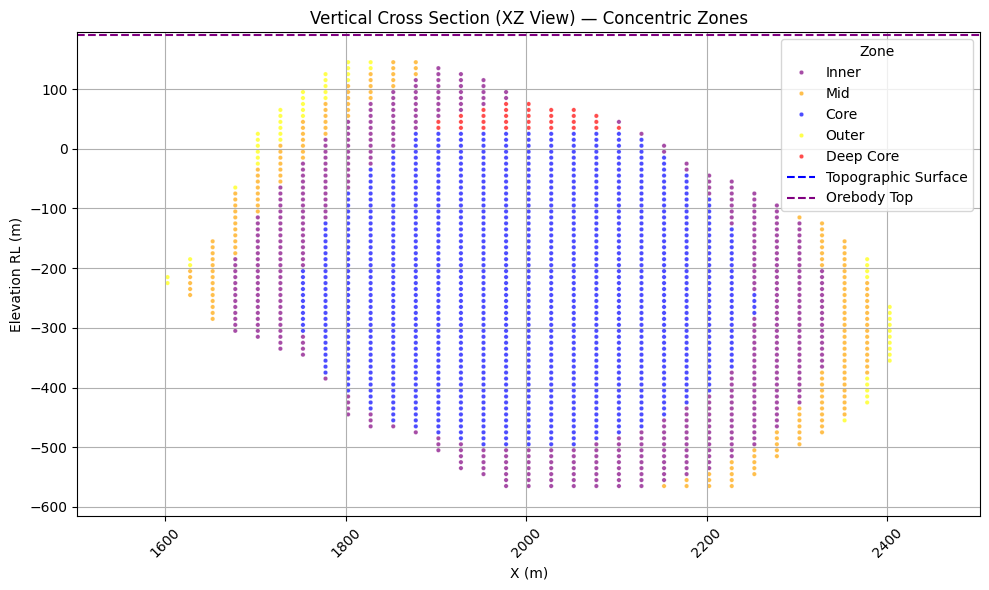

In [77]:
# ======================================================================
# 📦 STEP 2.4.1 : Vertical Cross Section to Confirm Tapering ###
# ======================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Pick a Y slice around the orebody center
y_center = orebody_center[1]
slice_thickness = block_size[1] * 1.1  # One block thick

# Filter block model
taper_df = block_model_df[
    (block_model_df["y"] > y_center - slice_thickness / 2) &
    (block_model_df["y"] < y_center + slice_thickness / 2)
]

# Restrict to orebody
taper_df = taper_df[
    taper_df["concentric_zone"].isin(["Deep Core", "Core", "Inner", "Mid", "Outer"])
]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=taper_df,
    x="x", y="z",
    hue="concentric_zone",
    palette={
        "Deep Core": "red",
		"Core": "blue",
		"Inner": "purple",
		"Mid": "orange",
		"Outer": "yellow"
    },
    s=10,
    alpha=0.7
)

plt.gca().invert_yaxis()
plt.title("Vertical Cross Section (XZ View) — Concentric Zones")
plt.xlabel("X (m)")
# Reverse y-axis to show depth
plt.xticks(rotation=45)
plt.xlim(taper_df["x"].min() - axis_adj[0], taper_df["x"].max() + axis_adj[0])
plt.ylim(taper_df["z"].min() - axis_adj[2], taper_df["z"].max() + axis_adj[2])
plt.axhline(y=topo_surface.mean(), color='blue', linestyle='--', label='Topographic Surface')
plt.axhline(y=orebody_top, color='purple', linestyle='--', label='Orebody Top')
plt.ylabel("Elevation RL (m)")
plt.legend(title="Zone", loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()


### 📦 **2.5: 2D Slice Viewer with Fault Zone Overlay**

This step provides a fast, interactive 2D visualisation of the block model along a **selectable slice axis** (`X`, `Y`, or `Z`), with the fault zone overlaid for visual validation.

- Blocks inside the fault zone are shown in **red**
- All other blocks are shown in **light grey**
- This tool helps confirm the **spatial geometry** of the fault: dip, azimuth, thickness, and position
- The slice axis and position are chosen using an interactive **data-aware slider**, which only allows values where block data exists

---

#### 🧭 Slice Orientation
- `Z` axis slice → **Plan view** (X-Y plane)
- `Y` axis slice → **X-Z cross section**
- `X` axis slice → **Y-Z cross section**

---

#### ⚙️ Customisation Options
- `slice_thickness`: Defines how thick the slice window is (± from selected value)
- `preview_mode`: Subsamples blocks to speed up rendering for large models
- Automatically resizes plot height for cross sections
- Automatically handles missing data (no empty plots)

---

#### ✅ Recommended Use
- As a **quick spatial validation tool** for fault geometry
- When working without 3D visualisation (`enable_3d_plot = False`)
- For generating clean visuals for reports or debugging

---

In [78]:
# ======================================================================
# 📦 STEP 2.5: 2D PLAN VIEW - FAULT ZONE OVERLAY ###
# ======================================================================

from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns

def plot_slice_with_fault(slice_axis, slice_value, slice_thickness=10, preview=True, df=None, ax=None):
	assert df is not None, "Block model DataFrame (`df`) is required."

	# Filter slice
	slice_df = df[np.abs(df[slice_axis] - slice_value) < slice_thickness]
	if preview and len(slice_df) > 20000:
		slice_df = slice_df.sample(n=20000, random_state=42)

	if slice_df.empty:
		print(f"⚠️ No data found at {slice_axis.upper()} = {slice_value} ± {slice_thickness}.")
		plt.figure(figsize=(8, 6))
		plt.text(0.5, 0.5, "No data at this slice", ha="center", va="center", fontsize=14)
		plt.axis("off")
		plt.show()
		return

	# Determine plotting axes (exclude the sliced one)
	xy_axes = [a for a in ["x", "y", "z"] if a != slice_axis]
	x_axis, y_axis = xy_axes

	if ax is None:
		plt.figure(figsize=(10, 8))
		ax = plt.gca()

	sns.scatterplot(
		data=slice_df,
		x=x_axis, y=y_axis,
		hue=slice_df["fault_name"].fillna("Orebody"),
		palette="Set1",
		alpha=0.6,
		edgecolor=None,
		ax=ax
	)


	ax.set_title(f"Plan View at {slice_axis.upper()} ≈ {slice_value:.1f} m (Fault Zones Highlighted)")
	ax.set_xlabel(f"{x_axis.upper()} (m)")
	ax.set_ylabel(f"{y_axis.upper()} (m)")
	ax.set_xlim(slice_df[x_axis].min() - axis_adj[0], slice_df[x_axis].max() + axis_adj[0])
	ax.set_ylim(slice_df[y_axis].min() - axis_adj[2], slice_df[y_axis].max() + axis_adj[2])
	ax.set_aspect("equal")
	ax.grid(True)
	# ax.invert_yaxis()
	ax.set_aspect('auto')
	ax.legend(title="In Fault Zone")


filtered_df = orebody_blocks.copy()

make_axis_slider(
	df=filtered_df,
	axis="y",  # or "x" or "z"
	label="Y Cross Section",
	callback_fn=plot_slice_with_fault,
	additional_args={"df": filtered_df},
	slice_thickness=10,
	preview=preview_mode
)

interactive(children=(SelectionSlider(continuous_update=False, description='Y Cross Section', index=13, layout…

### 📦 **2.6: Block Model Diagostics & Relationship Validation**

This step performs diagnostic checks to verify that the synthetic block model exhibits geologically and geometallurgically realistic behaviour — especially where inter-property dependencies have been applied.

---

#### 📈 Visual & Statistical Checks:

- **Pairplot matrix** for visualising correlations between key properties  
- **Correlation heatmap** to quantify relationships (positive/negative, strong/weak)  
- **Vertical profile viewer** to inspect continuity along depth  
- **Scatterplots with trendlines** to validate dependency rules (e.g. UCS → RMR)

---

These diagnostics help ensure the model respects intended physical relationships (e.g. harder rocks → lower Axb, higher BWi), and they provide confidence for downstream use in resource estimation, process modelling, or training workflows.

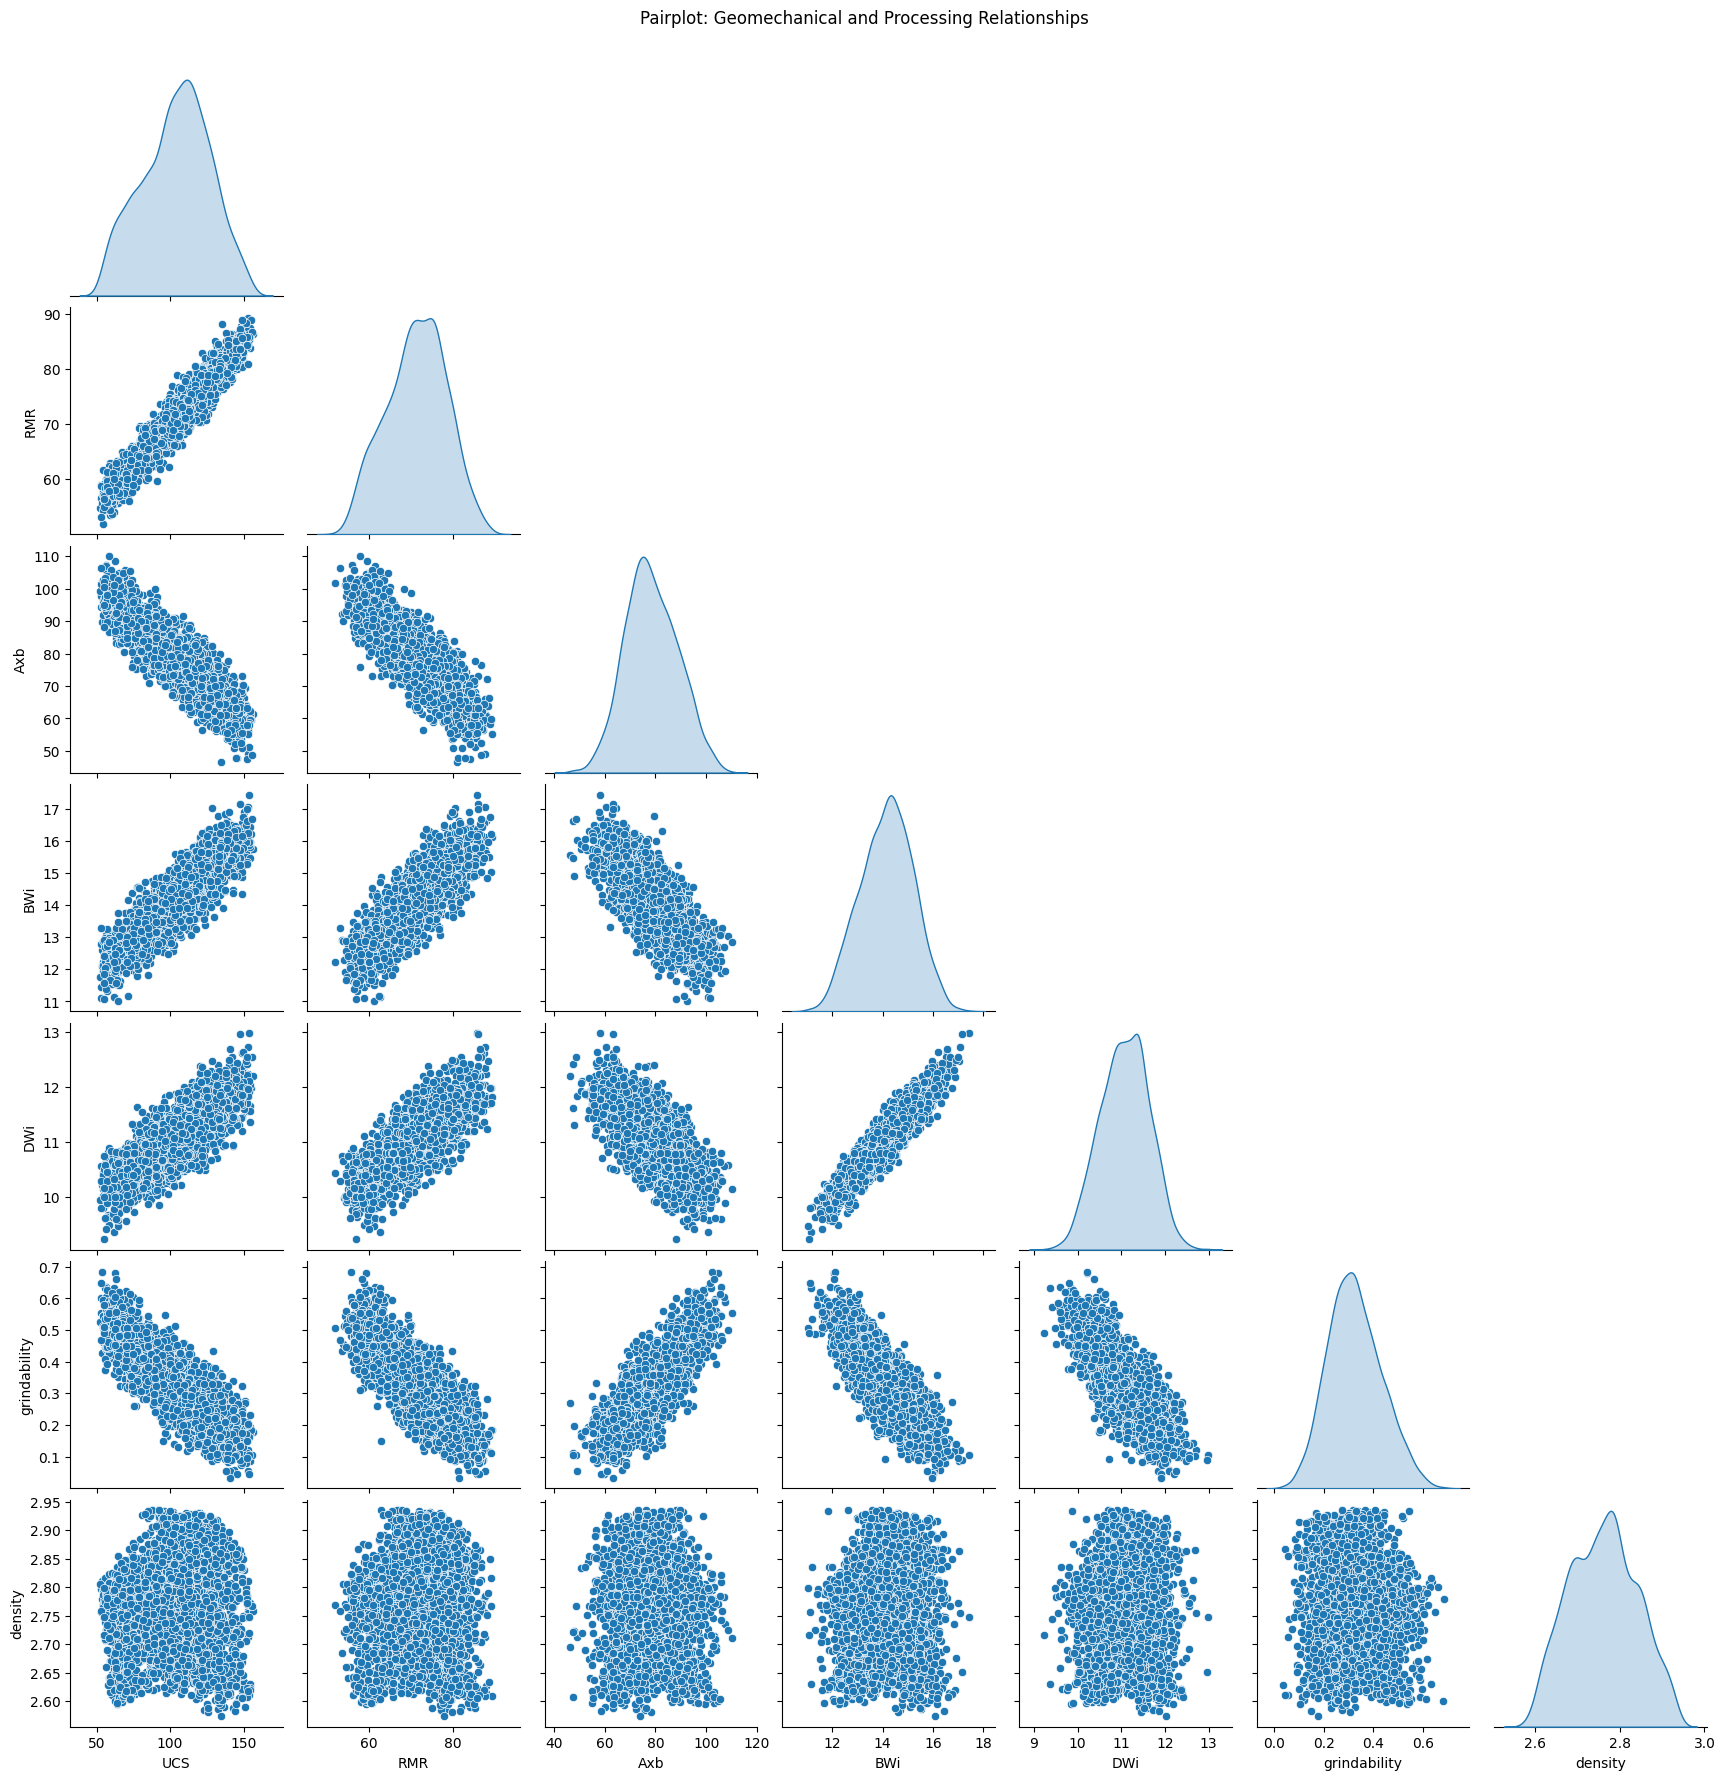

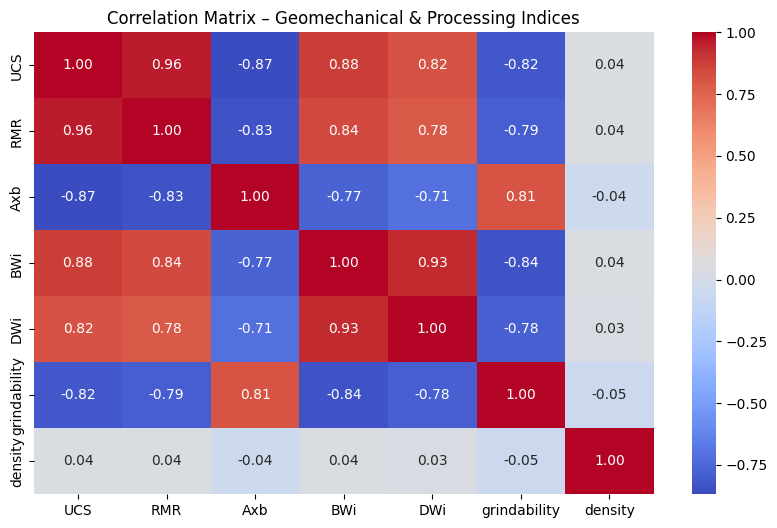

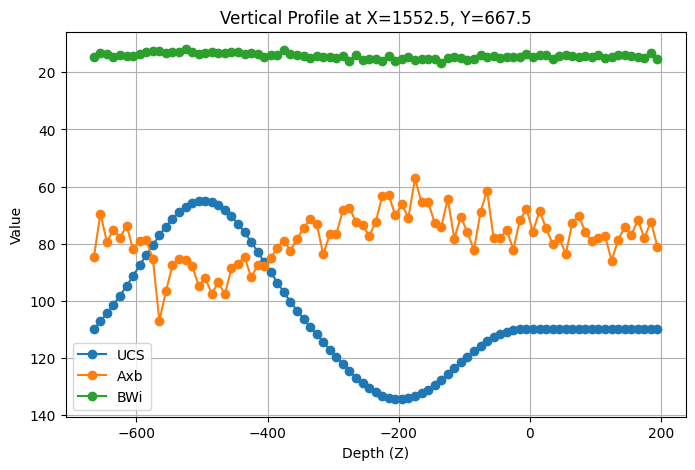

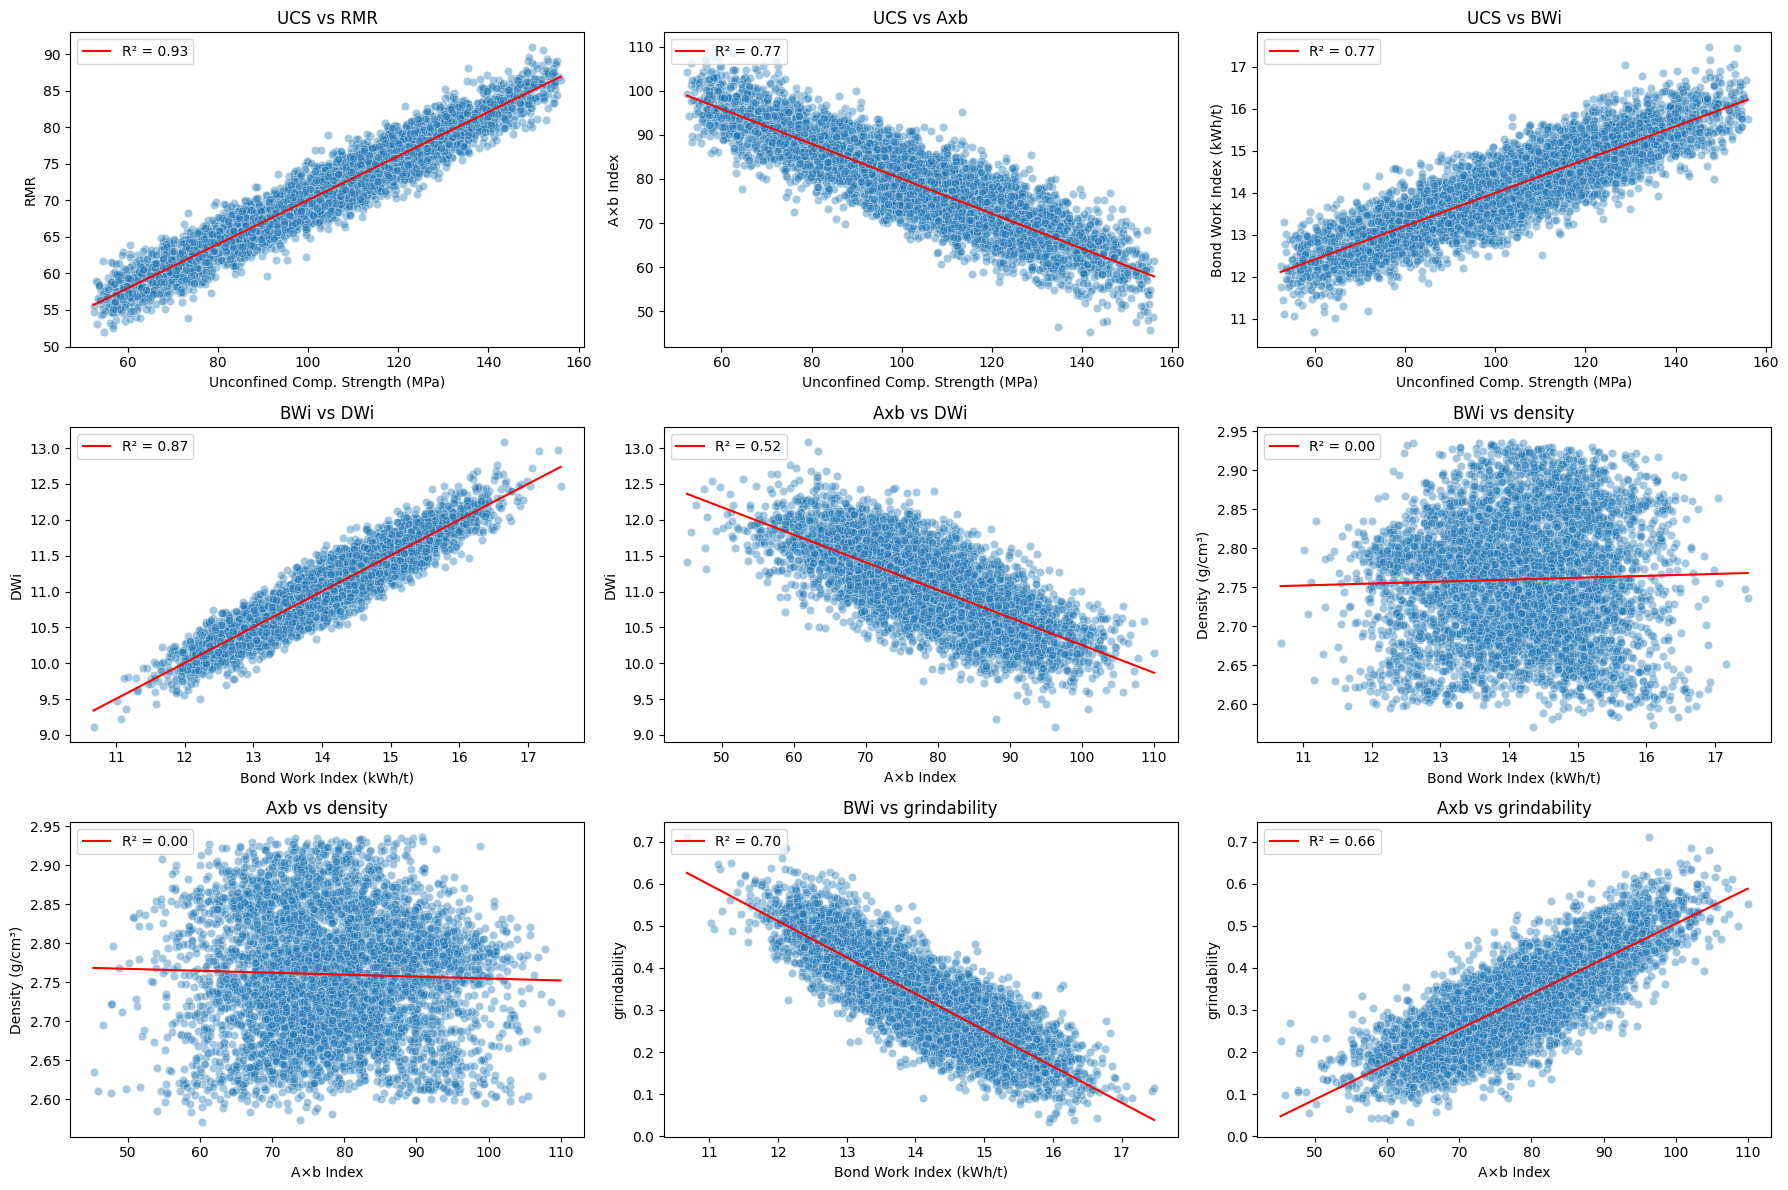

In [79]:
# ======================================================================
# 📦 STEP 2.6: BLOCK MODEL DIAGNOSTICS & RELATIONSHIP VALIDATION ###
# ======================================================================
from scipy.stats import linregress

# --- 1. Pairplot matrix ---
pairplot_cols = ["UCS", "RMR", "Axb", "BWi", "DWi", "grindability", "density"]
df_subset = block_model_df[pairplot_cols].dropna()

if preview_mode and len(df_subset) > max_pairplot_rows:
	df_subset = df_subset.sample(n=max_pairplot_rows, random_state=42)

sns.pairplot(df_subset, corner=True, diag_kind="kde")
plt.suptitle("Pairplot: Geomechanical and Processing Relationships", y=1.02)
plt.show()

# --- 2. Correlation matrix ---
corr = df_subset.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix – Geomechanical & Processing Indices")
plt.show()

# --- 3. Vertical continuity check at a fixed X,Y position ---

# Find nearest XY slice for diagnostic vertical section
x_target = block_model_df["x"].unique()[np.abs(block_model_df["x"].unique() - 250).argmin()]
y_target = block_model_df["y"].unique()[np.abs(block_model_df["y"].unique() - 250).argmin()]

# Select all blocks along this vertical column
profile_df = block_model_df[
	np.isclose(block_model_df["x"], x_target) & np.isclose(block_model_df["y"], y_target)
]

if profile_df.empty:
	print(f"No blocks found at X={x_target:.1f}, Y={y_target:.1f}")

# Plot vertical profiles for key properties
plt.figure(figsize=(8, 5))
for prop in ["UCS", "Axb", "BWi"]:
	if prop in profile_df.columns:
		plt.plot(profile_df["z"], profile_df[prop], label=prop, marker='o')

plt.gca().invert_yaxis()
plt.xlabel("Depth (Z)")
plt.ylabel("Value")
plt.title(f"Vertical Profile at X={x_target:.1f}, Y={y_target:.1f}")
plt.legend()
plt.grid(True)
plt.show()

# --- 4. Crossplots with trendlines ---
cross_plot_pairs = [
	("UCS", "RMR"),
	("UCS", "Axb"),
	("UCS", "BWi"),
	("BWi", "DWi"),
	("Axb", "DWi"),
	("BWi", "density"),
	("Axb", "density"),
	("BWi", "grindability"),
	("Axb", "grindability")
]

n_cols = 3
n_rows = int(np.ceil(len(cross_plot_pairs) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for idx, (x, y) in enumerate(cross_plot_pairs):
	ax = axes[idx]
	df_plot = block_model_df[[x, y]].dropna()

	if preview_mode and len(df_plot) > max_crossplot_rows:
		df_plot = df_plot.sample(n=max_crossplot_rows, random_state=42)

	if df_plot.empty:
		ax.set_title(f"No data for {x} vs {y}")
		continue

	sns.scatterplot(data=df_plot, x=x, y=y, alpha=0.4, ax=ax)

	slope, intercept, r_value, p_value, _ = linregress(df_plot[x], df_plot[y])
	x_vals = np.linspace(df_plot[x].min(), df_plot[x].max(), 100)
	y_vals = slope * x_vals + intercept
	ax.plot(x_vals, y_vals, color="red", label=f"R² = {r_value**2:.2f}")

	ax.set_title(f"{x} vs {y}")
	ax.set_xlabel(property_labels.get(x, x))
	ax.set_ylabel(property_labels.get(y, y))
	ax.legend(loc="upper left")

for i in range(len(cross_plot_pairs), len(axes)):
	fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### 🔹 **2.7: 3D Visualisation of Fault Zone (Red vs Grey)**

This 3D visualisation uses PyVista to display the entire block model:

- **Grey** blocks represent the full model.
- **Red** blocks represent those intersecting the fault zone.
- Transparency is applied to allow internal visibility of the fault.

This step helps confirm:
- Fault dip, azimuth and volume extent
- Spatial location of the fault relative to the orebody and block geometry


In [80]:
# ======================================================================
# 📦 STEP 2.7: VISUALISATION OF FAULT ZONE (RED vs GREY) ###
# ======================================================================
import pyvista as pv

# --- 1. Limit to blocks that are either in fault zone or orebody ---
fault_orebody_df = block_model_df[
	block_model_df["fault_category"] | (block_model_df["zone_code"] > 0)
].copy()

if fault_orebody_df.empty:
	print("⚠️ No blocks found in fault zone or orebody zone.")

# --- 2. Create point cloud ---
points = fault_orebody_df[["x", "y", "z"]].values
cloud = pv.PolyData(points)

# --- 3. Add fault zone membership as scalar ---
cloud["fault_category"] = fault_orebody_df["fault_category"].astype(int)

# --- 4. Extract block size ---
block_x, block_y, block_z = model_dimensions["block_size"]
cube = pv.Cube(x_length=block_x * 0.95,
			   y_length=block_y * 0.95,
			   z_length=block_z * 0.95)

# --- 5. Create separate masks on filtered DataFrame ---
fault_mask = fault_orebody_df["fault_category"]
non_fault_mask = ~fault_mask

# --- 6. Split into fault and non-fault point clouds ---
fault_points = points[fault_mask.values]
non_fault_points = points[non_fault_mask.values]

cloud_fault = pv.PolyData(fault_points)
cloud_non_fault = pv.PolyData(non_fault_points)

# --- 7. Create glyphs ---
glyphs_fault = cloud_fault.glyph(scale=False, geom=cube)
glyphs_non_fault = cloud_non_fault.glyph(scale=False, geom=cube)

# --- 8. Plot ---
plotter = pv.Plotter(notebook=True)
plotter.set_background("white")

plotter.add_mesh(glyphs_non_fault, color="lightgrey", opacity=0.5, lighting=False)
plotter.add_mesh(glyphs_fault, color="red", opacity=0.7, lighting=False)

plotter.view_isometric()
plotter.add_axes()
plotter.add_title("3D View of Fault Zone", font_size=14)
plotter.show()



Widget(value='<iframe src="http://localhost:53765/index.html?ui=P_0x25997d09a00_11&reconnect=auto" class="pyvi…

### 🔹 **2.8: 3D Fault Zone Coloured by Au Grade**

This visualisation shows the fault zone blocks in 3D, coloured by their simulated gold grade (`Au_grade`):

- All blocks are shown as **transparent grey** for context.
- Blocks within the fault zone are coloured using a **colormap (e.g., 'plasma')** based on `Au_grade`.

Purpose:
- Visually confirm whether grade enrichment logic is working inside the fault.
- Spot spatial patterns or clustering of high-grade blocks.


In [81]:
# ======================================================================
# 📦 STEP 2.8: 3D FAULT ZONE VIEWER COLOURED BY AU GRADE
# ======================================================================

# --- 1. Subset fault zone blocks ---
fault_blocks = block_model_df[block_model_df["fault_category"]]

# --- 2. Convert to PyVista PolyData ---
points = fault_blocks[["x", "y", "z"]].values
cloud = pv.PolyData(points)

# --- 3. Add attributes ---
cloud["Au_grade"] = fault_blocks["Au_grade"].values

# Add dummy scalar field to control glyph size uniformly
cloud["scale"] = np.full(cloud.n_points, block_size[0] * 1)

# --- 4. Generate glyphs (cubes) ---
cube = pv.Cube()
glyphs = cloud.glyph(scale="scale", geom=cube, orient=False)

# --- 5. Get consistent colorbar scaling ---
vmin, vmax = get_colorbar_limits("Au")

# --- 6. Plot ---
plotter = pv.Plotter(notebook=True)
plotter.set_background("white")

plotter.add_mesh(
	glyphs,
	scalars="Au_grade",
	cmap="plasma",
	opacity=1.0,
	show_scalar_bar=True,
	scalar_bar_args={
		"title": "Au Grade (g/t)",
		"title_font_size": 12,
		"label_font_size": 10
	},
	clim=[vmin, vmax]  # << Apply your min/max range here
)

plotter.view_isometric()
plotter.add_axes()
plotter.add_title("3D Fault Zone Coloured by Au Grade", font_size=14)
plotter.show()


Widget(value='<iframe src="http://localhost:53765/index.html?ui=P_0x25994893980_12&reconnect=auto" class="pyvi…

### 🔹 **2.9: 3D Fault Zone Coloured by Cu Grade**

This visualisation extends the 3D fault view by showing Copper (Cu) grade distribution within the fault zone, while still preserving the broader block model context in semi-transparent grey.

---

#### 🎯 What this step highlights:
* High-resolution 3D colouring of Cu grades (viridis colormap)
* Overlay of Cu-grade fault zone on top of full block model
* Visual inspection of potential spatial trends in copper associated with the fault

This view complements the previous Au-based colouring by helping users explore multi-element relationships within structurally complex zones.

---

In [82]:
# ======================================================================
# 📦 STEP 2.9: 3D FAULT ZONE VIEWER COLOURED BY CU GRADE
# ======================================================================

# --- 1. Reuse existing fault_blocks and cube ---
points = fault_blocks[["x", "y", "z"]].values
cloud = pv.PolyData(points)

# --- 2. Add Cu grade and uniform scaling ---
cloud["Cu_grade"] = fault_blocks["Cu_grade"].values
cloud["scale"] = np.full(cloud.n_points, block_size[0] * 1)

# --- 3. Generate glyphs ---
glyphs = cloud.glyph(scale="scale", geom=cube, orient=False)

# --- 4. Get color scale limits for Cu ---
vmin, vmax = get_colorbar_limits("Cu")

# --- 5. Plot ---
plotter = pv.Plotter(notebook=True)
plotter.set_background("white")

plotter.add_mesh(
	glyphs,
	scalars="Cu_grade",
	cmap=property_colormaps.get("Cu_grade", "viridis"),
	opacity=1.0,
	show_scalar_bar=True,
	scalar_bar_args={
		"title": property_labels.get("Cu_grade", "Cu Grade (%)"),
		"title_font_size": 12,
		"label_font_size": 10
	},
	clim=[vmin, vmax]
)

plotter.view_isometric()
plotter.add_axes()
plotter.add_title("3D Fault Zone Coloured by Cu Grade", font_size=14)
plotter.show()


Widget(value='<iframe src="http://localhost:53765/index.html?ui=P_0x259976c77d0_13&reconnect=auto" class="pyvi…

### 🔹**2.10: Visualising Fault Core and Damage Halo**

This visualisation highlights both the core fault zone and its surrounding damage halo, based on spatial distance from the curved fault plane defined earlier.

---

🎯 Purpose:
This step visualises the **realistic fault zone geometry** using a transparent full block model and highlighting:
- 🟥 **Fault core** blocks (intensely sheared)
- 🟧 **Damage halo** blocks (fractured but not fully sheared)

This visual is useful for understanding how fault structures interact with orebody geometry, block accessibility, and mining layout.

---

📊 What It Shows:
- By rendering the background model in **light grey** with high transparency, the viewer can clearly see both:
- The spatial continuity and curvature of the fault core  
- The extent and thickness of the surrounding damage halo  

This visualisation is useful for validating structural realism and will support any downstream analysis of grade enrichment, rock strength weakening, or blasting design implications across these zones.

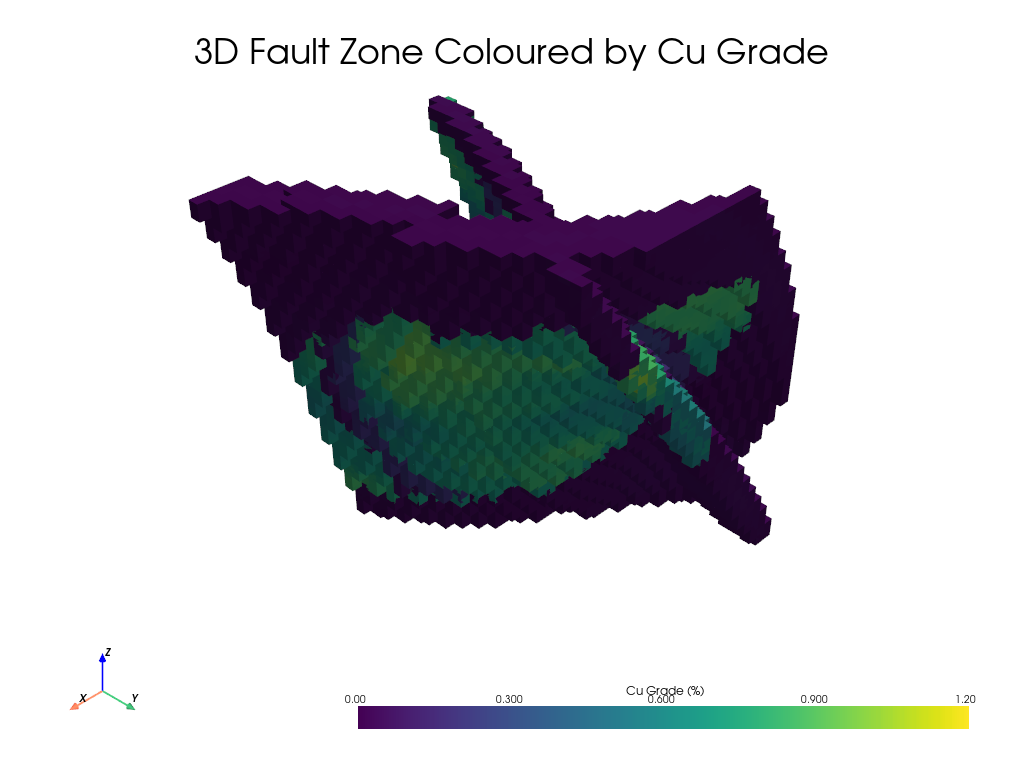

In [83]:
# ======================================================================
# 📦 STEP 2.10: VISUALISATION OF FAULT CORE AND DAMAGE HALO ###
# ======================================================================

# --- 1. Extract block size and cube geometry ---
block_x, block_y, block_z = model_dimensions["block_size"]
cube = pv.Cube(x_length=block_x * 0.9, y_length=block_y * 0.9, z_length=block_z * 0.9)

# --- 2. Split categories ---
for fault_name in block_model_df["fault_name"].dropna().unique():
    core_mask = block_model_df["fault_zone_category"].eq("core") & block_model_df["fault_name"].eq(fault_name)
    halo_mask = block_model_df["fault_zone_category"].eq("halo") & block_model_df["fault_name"].eq(fault_name)

    cloud_core = pv.PolyData(block_model_df[core_mask][["x", "y", "z"]].values)
    cloud_halo = pv.PolyData(block_model_df[halo_mask][["x", "y", "z"]].values)

    glyphs_core = cloud_core.glyph(scale=False, geom=cube, orient=False)
    glyphs_halo = cloud_halo.glyph(scale=False, geom=cube, orient=False)

    plotter.add_mesh(glyphs_halo, color="orange", opacity=0.8)
    plotter.add_mesh(glyphs_core, color="red", opacity=1.0)

# Add non-fault blocks in the background
non_fault_mask = block_model_df["fault_zone_category"] == "none"
cloud_none = pv.PolyData(block_model_df[non_fault_mask][["x", "y", "z"]].values)
glyphs_none = cloud_none.glyph(scale=False, geom=cube, orient=False)
plotter.add_mesh(glyphs_none, color="lightgrey", opacity=0.03)

plotter.view_isometric()
plotter.add_axes()
plotter.add_title("3D View of Fault Core and Damage Halo", font_size=14)
plotter.show(jupyter_backend='static')


## 🖼️ **Step 3: Block Model Visualisation**

This step provides multiple visualisation modes to inspect the synthetic block model. These views help verify spatial continuity, domain structure, and property distribution across the model’s geometry.

---

#### 🔹 **3.1: Static Visualisation**

- **Horizontal Slices (Z-level)** – Top-down views at user-selected depths
- **Vertical Sections (Y or X)** – Cross-sections through the model (default is Y)
- **3D Scatter Plot** – Interactive 3D view using Plotly for spatial inspection

Each visualisation is dynamically linked to the selected `primary_mineral`, and uses appropriate colourmaps and axis scaling.

In [84]:
# ======================================================================
# 📦 STEP 3.1: INTERACTIVE BLOCK MODEL VIEWS (Plan, Section, 3D)
# ======================================================================

import matplotlib.pyplot as plt
import plotly.express as px
import ipywidgets as widgets
from IPython.display import clear_output

# --- 3.1.1 HORIZONTAL SLICE VIEWER (Z-LEVEL) ---
def plot_horizontal_slice(slice_axis, slice_value, slice_thickness=None, df=None, **kwargs):
	assert df is not None, "Block model DataFrame (`df`) is required."

	if slice_thickness is None:
		slice_thickness = model_dimensions["block_size"][2]  # Z thickness

	# Filter slice
	slice_df = df[np.abs(df[slice_axis] - slice_value) <= (slice_thickness / 2)]

	# Filter to grade threshold
	slice_df = slice_df[
		(slice_df["Au_grade"] >= cuttoff_au_visuals)
	]

	if slice_df.empty:
		print(f"⚠️ No valid ore blocks found at {slice_axis.upper()} = {slice_value} m.")
		return

	pivot = slice_df.pivot_table(index='y', columns='x', values='Au_grade', aggfunc='mean').fillna(0)
	cmap = property_colormaps.get("Au_grade", 'plasma')
	vmin, vmax = get_colorbar_limits("Au")  # Use Au base + multiplier

	plt.figure(figsize=(6, 6))
	plt.imshow(pivot.values, origin='lower', cmap=cmap,
			   extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()],
			   vmin=vmin, vmax=vmax)
	plt.title(f"Horizontal Slice at Z = {slice_value} m")
	plt.colorbar(label="Au Grade (g/t)")
	plt.xlabel("X (m)")
	plt.ylabel("Y (m)")
	plt.xlim(pivot.columns.min() - axis_adj[0], pivot.columns.max() + axis_adj[0])
	plt.ylim(pivot.index.min() - axis_adj[1], pivot.index.max() + axis_adj[1])
	plt.grid(False)
	plt.show()

make_axis_slider(
	df=block_model_df,
	axis="z",
	label="Z-Level Slice (Plan View)",
	callback_fn=plot_horizontal_slice,
	additional_args={"df": block_model_df},
	slice_thickness=block_size[2] / 2
)

# --- 3.1.2 VERTICAL CROSS-SECTION VIEWER (Y-LEVEL) ---
def plot_vertical_section(slice_axis, slice_value, slice_thickness=None, df=None, **kwargs):
	assert df is not None, "Block model DataFrame (`df`) is required."

	if slice_thickness is None:
		slice_thickness = model_dimensions["block_size"][1]  # Y thickness

	# Filter slice
	slice_df = df[np.abs(df[slice_axis] - slice_value) <= (slice_thickness / 2)]

	# Filter to ore only and grade threshold
	slice_df = slice_df[
		(slice_df["Au_grade"] >= cuttoff_au_visuals)
	]

	if slice_df.empty:
		print(f"⚠️ No valid ore blocks found at {slice_axis.upper()} = {slice_value} m.")
		return

	pivot = slice_df.pivot_table(index='z', columns='x', values='Au_grade', aggfunc='mean').fillna(0)
	cmap = property_colormaps.get("Au_grade", 'plasma')
	vmin, vmax = get_colorbar_limits("Au")

	plt.figure(figsize=(10, 6))
	plt.imshow(pivot.values, origin='lower', cmap=cmap,
			   extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()],
			   vmin=vmin, vmax=vmax)
	plt.title(f"Vertical Cross Section at Y = {slice_value} m")
	plt.colorbar(label="Au Grade (g/t)")
	plt.xlabel("X (m)")
	plt.ylabel("Z (m)")
	plt.xlim(pivot.columns.min() - axis_adj[0], pivot.columns.max() + axis_adj[0])
	plt.ylim(pivot.index.min() - axis_adj[2], pivot.index.max() + axis_adj[2])
	plt.grid(False)
	plt.gca().invert_yaxis()  # Depth convention
	plt.show()


valid_y = get_valid_slice_positions(block_model_df, axis='y', required_axis='z')

make_axis_slider(
	df=block_model_df[block_model_df["y"].isin(valid_y)],
	axis="y",
	label="Y Cross Section (Vertical View)",
	callback_fn=plot_vertical_section,
	additional_args={"df": block_model_df},
	slice_thickness=model_dimensions["block_size"][1]
)

# --- 3.1.3 3D BLOCK MODEL VIEW ---

ore_blocks = block_model_df[
	(block_model_df["Au_grade"] >= cuttoff_au_visuals)
]

sample_df = ore_blocks.sample(frac=0.2, random_state=1)

cmap = property_colormaps.get(primary_mineral, 'plasma')
vmin, vmax = get_colorbar_limits(primary_mineral.split("_")[0])

sample_df["Au_grade_fmt"] = sample_df["Au_grade"].round(2)
hover_data = {
	"x": True,
	"y": True,
	"z": True,
	"Au_grade_fmt": True,
	"concentric_zone": True
}

fig = px.scatter_3d(
	sample_df,
	x='x', y='y', z='z',
	color="Au_grade",
	color_continuous_scale=cmap,
	range_color=[vmin, vmax],
	hover_data=hover_data,
	opacity=0.6,
	size_max=2,
	title="3D Block Model – Au Grade (g/t)",
	labels={"Au_grade": "Au Grade (g/t)"}
)

fig.update_layout(
	scene=dict(
		xaxis_title='X (m)',
		yaxis_title='Y (m)',
		zaxis_title='Z (m)',
		xaxis=dict(
			nticks=4,
			range=[sample_df["x"].min() - axis_adj[0], sample_df["x"].max() + axis_adj[0]]
			),
		yaxis=dict(
			nticks=4,
			range=[sample_df["y"].min() - axis_adj[1], sample_df["y"].max() + axis_adj[1]]
			),
		zaxis=dict(
			nticks=4,
			range=[sample_df["z"].min() - axis_adj[2], sample_df["z"].max() + axis_adj[2]]
			),
	),
	margin=dict(l=0, r=0, b=0, t=30)
)
fig.show()


interactive(children=(SelectionSlider(continuous_update=False, description='Z-Level Slice (Plan View)', index=…

interactive(children=(SelectionSlider(continuous_update=False, description='Y Cross Section (Vertical View)', …

#### 🎞️ **Step 3.2: Animated Depth Slices**

Scroll through Z-level slices to simulate moving **downward through the deposit**. This animation helps visualise how mineral grades (or other properties) vary with depth and provides a dynamic overview of spatial continuity.

---

- Automatically steps through all Z levels using `primary_mineral` as the visualised property
- Useful for detecting vertical patterns, layering, or abrupt transitions
- Colour scale is fixed to allow consistent comparison between frames

In [85]:
# ======================================================================
# 📦 STEP 3.2: ANIMATED DEPTH SLICES
# ======================================================================

from matplotlib import animation
from IPython.display import HTML

# --- Prepare Z-levels ---
z_levels = sorted(block_model_df['z'].unique())

# Use colormap and colour scale from primary mineral
cmap = property_colormaps.get(primary_mineral, 'plasma')
vmin, vmax = get_colorbar_limits(primary_mineral.split("_")[0])

# --- Initialise plot ---
fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(np.zeros((10, 10)), cmap=cmap, origin='lower',
				extent=[0, extent[0], 0, extent[1]],
				vmin=vmin, vmax=vmax)

# Colourbar
cbar = plt.colorbar(img, ax=ax)
cbar.set_label(property_labels.get(primary_mineral, primary_mineral))

# --- Frame update function ---
def update(frame):
	z_val = z_levels[frame]
	slice_df = block_model_df[
		(block_model_df["z"] == z_val) &
		(block_model_df["Au_grade"] >= cuttoff_au_visuals)
	]

	if slice_df.empty:
		img.set_data(np.zeros((10, 10)))
		img.set_extent([0, extent[0], 0, extent[1]])
	else:
		pivot = slice_df.pivot_table(index='y', columns='x', values=primary_mineral, aggfunc='mean').fillna(0)
		img.set_data(pivot.values)
		img.set_extent([pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()])

	ax.set_title(f"{property_labels.get(primary_mineral, primary_mineral)} – Z = {z_val} m")
	return [img]

# --- Run animation ---
ani = animation.FuncAnimation(fig, update, frames=len(z_levels), interval=500)
plt.close()
HTML(ani.to_jshtml())



#### 🧭 **3.3: Interactive Property Viewer**

Use dropdown menus to explore different properties (e.g. `Au_grade`, `Cu_grade`, `density`) at specific Z levels. This widget-based viewer allows quick inspection of vertical slice data across all available variables.

---

- Built using `ipywidgets` for interactivity within Jupyter
- Supports any numerical property included in the block model
- Auto-detects colourmaps and labels based on user configuration

In [86]:
# ======================================================================
# 📦 STEP 3.3: INTERACTIVE PROPERTY VIEWER (with Slider)
# ======================================================================

from IPython.display import display, clear_output

# --- 1. Dropdown to choose property ---
property_dropdown = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z', 'block_id']],
	value=primary_mineral,
	description='Property:'
)

# --- 2. Interactive Plotting Function ---
def plot_interactive_slice(slice_axis, slice_value, slice_thickness=None, df=None, property_name=None, **kwargs):
	clear_output(wait=True)
	display(property_dropdown)  # Re-display dropdown after clearing

	assert df is not None, "Block model DataFrame (`df`) is required."
	if property_name not in df.columns:
		print(f"⚠️ Property '{property_name}' not found in block model.")
		return

	if slice_thickness is None:
		slice_thickness = model_dimensions["block_size"][2]  # Z block thickness

	# Subset slice
	slice_df = df[np.abs(df[slice_axis] - slice_value) <= (slice_thickness / 2)]
	if slice_df.empty:
		print(f"⚠️ No blocks found at {slice_axis.upper()} = {slice_value} ± {slice_thickness}.")
		return

	prop_series = slice_df[property_name]
	is_numeric = pd.api.types.is_numeric_dtype(prop_series)
	aggfunc = "mean" if is_numeric else "first"
	label = property_labels.get(property_name, property_name)

	try:
		pivot = slice_df.pivot_table(index="y", columns="x", values=property_name, aggfunc=aggfunc).fillna(0)
	except Exception as e:
		print(f"⚠️ Pivot failed for '{property_name}' with error: {e}")
		return

	plt.figure(figsize=(6, 6))

	if is_numeric:
		cmap = property_colormaps.get(property_name, "plasma")
		vmin, vmax = property_display_ranges.get(property_name, (None, None))
		im = plt.imshow(
			pivot.values,
			cmap=cmap,
			origin="lower",
			extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()],
			vmin=vmin,
			vmax=vmax
		)
		plt.colorbar(im, label=label)
	else:
		categorical_df = slice_df.copy()
		categorical_df["cat_code"] = categorical_df[property_name].astype("category").cat.codes
		code_map = dict(enumerate(categorical_df[property_name].astype("category").cat.categories))
		pivot = categorical_df.pivot_table(index="y", columns="x", values="cat_code", aggfunc="first").fillna(-1)

		im = plt.imshow(
			pivot.values,
			cmap="tab20",
			origin="lower",
			extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()]
		)
		cbar = plt.colorbar(im)
		ticks = list(code_map.keys())
		labels = [str(code_map[k]) for k in ticks]
		cbar.set_ticks(ticks)
		cbar.set_ticklabels(labels)
		cbar.set_label(label)

	plt.title(f"{label} at Z = {slice_value} m")
	plt.xlabel("X (m)")
	plt.ylabel("Y (m)")
	plt.grid(False)
	plt.show()

# --- 3. Slider + Viewer Trigger ---
def trigger_slider_viewer(change=None):
	clear_output(wait=True)
	display(property_dropdown)

	make_axis_slider(
		df=block_model_df,
		axis="z",
		label="Z-Level Slice",
		callback_fn=plot_interactive_slice,
		additional_args={
			"df": block_model_df,
			"property_name": property_dropdown.value
		},
		slice_thickness=model_dimensions["block_size"][2]
	)

# Call once on load
trigger_slider_viewer()

# Link dropdown change to rerender the slider
property_dropdown.observe(trigger_slider_viewer, names='value')


Dropdown(description='Property:', index=2, options=('zone_code', 'concentric_zone', 'Au_grade', 'Cu_grade', 'f…

interactive(children=(SelectionSlider(continuous_update=False, description='Z-Level Slice', index=43, layout=L…

## **Step 4: Export Block Model to CSV**

By this stage, the synthetic block model contains:

- **Spatial coordinates** (`x`, `y`, `z`)
- **Mineral grades** (e.g. `Au`, `Cu`)
- **Geophysical, geomechanical, and processing data**
- **Domain assignments** (`Orebody`, `Core`, `Background`)
- **Value-based classification** (`Ore` vs `Waste`)

You can now export the block model for downstream use in:

- External software (e.g. Excel, Deswik, Vulcan, Power BI)
- Further geostatistical, economic, or scheduling analysis
- Data versioning or sharing across platforms

Three export formats are supported:

- **CSV** – General-purpose, human-readable
- **Parquet** – Efficient for large datasets, ideal for reimport into Pandas
- **JSON (line-delimited)** – Web/API-friendly for lightweight workflows

🗂️ Files will be saved to: `../data/`


In [87]:
import os

# --- Set export directory and filenames ---
export_path = "../data/"
filename_base = "synthetic_block_model"
os.makedirs(export_path, exist_ok=True)

# Define full paths
csv_path = os.path.join(export_path, f"{filename_base}.csv")
parquet_path = os.path.join(export_path, f"{filename_base}.parquet")
json_path = os.path.join(export_path, f"{filename_base}.json")

# --- Export block model in multiple formats ---

# CSV: Human-readable, good for Excel/GIS
block_model_df.to_csv(csv_path, index=False)

# Parquet: Efficient binary format for Pandas reimport
block_model_df.to_parquet(parquet_path, index=False)

# JSON (line-delimited): Lightweight, API-compatible
block_model_df.to_json(json_path, orient="records", lines=True)

# --- Confirm successful export ---
print("✅ Block model exported successfully:")
print(f"  • CSV:     {csv_path}")
print(f"  • Parquet: {parquet_path}")
print(f"  • JSON:    {json_path}")


✅ Block model exported successfully:
  • CSV:     ../data/synthetic_block_model.csv
  • Parquet: ../data/synthetic_block_model.parquet
  • JSON:    ../data/synthetic_block_model.json


## 🧾 **Step 5: Add Economics to the Block Model**

This step integrates **economic logic** into the synthetic block model:

---

### 💰 Block Valuation
Each block is assigned a **value per tonne** using:

$$
\text{\color{Aquamarine} \text{Value per tonne}} = \sum_i \left( \text{Grade}_i \times \text{Recovery}_i \times \text{Price}_i \right)
$$

- Handles unit conversion (e.g. gold in oz, copper in %)  
- Applies recovery factors and exchange rates  
- Generates value columns per mineral and a total `value_per_tonne`

---

### 🧪 Value-Based Filtering and Visualisation
- Dynamic visualisation tools for `value_per_tonne` and related fields  
- Optional cut-off classification (`Ore` vs `Waste`)  
- Interactive viewers for inspecting economic distribution

---

These steps simulate early-stage economic filtering and enable downstream analysis such as pit shell generation or resource classification.


### 💻 **Step 5.1: Compute Value Per Tonne**

Each block is assigned an estimated **economic value per tonne**, based on:

---

#### ⚙️ Mineral-Specific Logic:
- `Au` (Gold): Recovery-adjusted grade × price (USD/oz → AUD/g)
- `Cu` (Copper): Recovery-adjusted grade × price (USD/lb → AUD/kg)
- Handles other unit types automatically (`oz`, `%`, etc.)

---

#### 💱 Currency Conversion:
- All values are converted to the selected `target_currency` (e.g., AUD)
- Exchange rates are applied during the price conversion step

---

#### ➕ Total Value:
- Individual mineral values (`value_Au_per_tonne`, `value_Cu_per_tonne`, etc.)  
- Summed to calculate a **total block value**: `value_per_tonne`

This enables downstream economic filtering, cutoff classification, and mine planning.


In [88]:
# ======================================================================
# 📦 STEP 5.1: COMPUTE VALUE PER TONNE ###
# ======================================================================

# Assign currency tag for tracking
block_model_df['currency'] = target_currency

# --- Compute value per tonne for each mineral ---
for mineral, econ in economic_data.items():
	grade_col = f"{mineral}_grade"
	value_col = f"value_{mineral}_per_tonne"

	# Skip if grade column is missing
	if grade_col not in block_model_df.columns:
		continue

	recovery = econ["recovery"]
	unit = econ["unit"]
	exchange = exchange_rates[target_currency]

	if unit == "oz":
		# Convert USD/oz → AUD/g
		price_per_g = (econ["price_per_oz_usd"] / OZ_TO_GRAMS) * exchange
		block_model_df[value_col] = block_model_df[grade_col] * recovery * price_per_g

	elif unit == "%":
		# Convert USD/lb → AUD/kg, then apply grade as % (kg/t)
		price_per_kg = (econ["price_per_lb_usd"] / LB_TO_KG) * exchange
		block_model_df[value_col] = block_model_df[grade_col] * recovery * price_per_kg * 10  # % → kg/t

	else:
		raise ValueError(f"❌ Unknown unit type for {mineral}: '{unit}'")

# --- Total value across all minerals ---
value_cols = [col for col in block_model_df.columns
			  if col.startswith("value_") and col.endswith("_per_tonne")]

block_model_df["value_per_tonne"] = block_model_df[value_cols].sum(axis=1)


### 🧭 **Step 5.2: Visualise Block Value Per Tonne**

Use the **interactive viewer** to explore how block-level economic value is distributed across the deposit.

---

#### 🔍 What you can explore:
- `value_per_tonne` – Total value from all minerals
- `value_Au_per_tonne`, `value_Cu_per_tonne` – Individual mineral contributions
- Other related metrics: `Au_grade`, `Cu_grade`, `density`

---

#### 🛠️ How it works:
- Select a **value-related column** from the dropdown
- Adjust the **Z-level slice** using the interactive slider
- View how value changes across depth and location

This is a powerful diagnostic to **validate block value logic**, confirm cut-off behavior, and assess how different attributes affect economic outcomes.

In [89]:
# ======================================================================
# 📦 STEP 5.2: VISUALISE BLOCK VALUE PER TONNE
# ======================================================================

from IPython.display import clear_output, display

# --- 1. Define filtered dropdown for value/tonne-related columns ---
exclude_cols = ['x', 'y', 'z', 'block_id', 'currency']
value_cols = [col for col in block_model_df.columns if "value" in col.lower() and col not in exclude_cols]

value_dropdown = widgets.Dropdown(
	options=value_cols,
	value=value_cols[0] if value_cols else None,
	description='Value Column:'
)

# --- 2. Trigger viewer with custom dropdown ---
def trigger_value_slider(change=None):
	clear_output(wait=True)
	display(value_dropdown)

	make_axis_slider(
		df=block_model_df,
		axis="z",
		label="Z-Level Slice",
		callback_fn=plot_interactive_slice,
		additional_args={
			"df": block_model_df,
			"property_name": value_dropdown.value
		},
		slice_thickness=model_dimensions["block_size"][2]
	)

# Initial render
trigger_value_slider()

# Re-render if user changes dropdown
value_dropdown.observe(trigger_value_slider, names="value")


Dropdown(description='Value Column:', options=('value_Au_per_tonne', 'value_Cu_per_tonne', 'value_per_tonne'),…

interactive(children=(SelectionSlider(continuous_update=False, description='Z-Level Slice', index=43, layout=L…

### 🪨 **Step 5.3: Classify Blocks – ORE vs WASTE**

Apply a basic economic **cut-off threshold** to classify blocks as either **Ore** or **Waste**, based on their `value_per_tonne`:

---

#### ⚙️ Logic:
- Uses the default cut-off: `150 AUD/t`  
- Adds a new column: `class` → values are either `"Ore"` or `"Waste"`

---

#### 📦 Purpose:
- Simulates a basic **resource classification** stage
- Enables filtering and plotting of economic material
- Supports downstream **mine planning**, **scheduling**, and **value tracking**

In [90]:
# ======================================================================
# 📦 STEP 5.3: VISUALISE BLOCK VALUE PER TONNE
# ======================================================================

# --- Classify each block as 'Ore' or 'Waste' ---
block_model_df['class'] = np.where(
	block_model_df['value_per_tonne'] >= value_cutoff,
	'Ore',
	'Waste'
)

# --- Display basic statistics for validation ---

# Value distribution
print("Value per tonne (summary):")
print(block_model_df['value_per_tonne'].describe())

# Ore vs Waste distribution
print("\nBlock classification counts:")
print(block_model_df['class'].value_counts())


Value per tonne (summary):
count    84437.000000
mean        93.296128
std         85.301300
min          4.957971
25%          8.500957
50%         65.189788
75%        169.126860
max        409.829565
Name: value_per_tonne, dtype: float64

Block classification counts:
class
Waste    53102
Ore      31335
Name: count, dtype: int64


## 🧱 **Step 6: Geological Domains**

Now that each block has an assigned value and classification, we’ll add **geological domains** to provide spatial structure. These domains simulate realistic orebody geometry — useful for filtering, reporting, and later-stage scheduling or visualisation.

---

#### 🧭 Why Use Domains?

- Visually **highlight geologically significant regions** (e.g. core vs halo)
- Enable **selective filtering** (e.g. value within the Core only)
- Support spatial logic in **Mine-to-Mill optimisation or scheduling**

---

#### 🔁 What Happens in Step 6?

| Substep | Purpose |
|--------|---------|
| **6.1** | Assign each block to a geological domain (e.g. *Core*, *Orebody*, *Background*) based on its `(x, y, z)` position |
| **6.2** | Compute high-level summary stats per domain (e.g. mean value, ore % share) |
| **6.3** | Visualise and compare average value per tonne by domain, with a bar chart and domain-filtered 2D viewer |
| **6.4** | Interactive viewer to explore different properties and domains with Z-slice filtering |
| **6.5** | Generate full descriptive statistics (mean, std, min, max) for each domain and key attributes |

Each step builds up a richer picture of how **geology influences value and planning decisions**.

---

### 📐 **Step 6.1: Define Domain Geometry**

Each block in the model is assigned a **geological domain** based on its spatial location:

- **Orebody**: A cylindrical or ellipsoidal ore zone (e.g. vertical ore shoot)
- **Core**: A high-grade inner ellipsoid nested within the orebody
- **Background**: All blocks outside the defined ore domains

---

#### 🛠️ Method:
- Uses `is_in_domain()` to test each block’s `(x, y, z)` against defined geometries
- Domains are applied in **priority order**, with later matches overwriting earlier ones
- A progress bar shows real-time updates using `tqdm`

---

#### 📊 Result:
- A new `domain` column is added to `block_model_df`
- Enables domain-specific filtering, plotting, or statistics

In [91]:
# ======================================================================
# 📦 STEP 6.1: DEFINE DOMAIN GEOMETRY ###
# ======================================================================

def assign_domains(df, domain_defs):
	domain_flags = []

	# Use tqdm for progress bar
	for _, row in tqdm(df.iterrows(), total=len(df), desc="Assigning domains"):
		label = "Background"  # Default
		for name, params in domain_defs.items():
			if is_in_domain(row, params):
				label = name
		domain_flags.append(label)

	df["domain"] = domain_flags
	return df

# --- Tag each block with a geological domain ---
block_model_df = assign_domains(block_model_df, domain_definitions)

# --- Summary output ---
print("\nDomain counts:")
print(block_model_df["domain"].value_counts())


Assigning domains:   0%|          | 0/84437 [00:00<?, ?it/s]


Domain counts:
domain
Orebody       50012
Background    34425
Name: count, dtype: int64


### 📊 **6.2: Summary Statistics by Domain**

This step generates a table of **key economic and geological metrics** for each defined geological domain:

---

#### 💎 Included Metrics:
- **Value per tonne** – Mean, standard deviation, min, max  
- **Gold & Copper grades** – Mean and standard deviation  
- **Ore block count** – Number of blocks above cut-off (`class = 'Ore'`)  
- **Ore percentage** – Share of ore blocks relative to total in domain  
- **Total blocks** – Proxy for domain size or volume

---

These statistics help validate:
- Whether **domain-based economics** align with geological expectations  
- If the model reflects **spatial variability** in value and grade  
- Which domains offer the **strongest economic potential**

Use this for **high-level insights** before detailed scheduling or pit optimisation.

In [92]:
# ======================================================================
# 📦 STEP 6.2: SUMMARY STATISTICS BY DOMAIN ###
# ======================================================================

# --- Compute summary statistics grouped by domain ---

domain_summary = block_model_df.groupby('domain').agg({
	'value_per_tonne': ['mean', 'std', 'min', 'max'],
	'Au_grade': ['mean', 'std'],
	'Cu_grade': ['mean', 'std'],
	'class': lambda x: (x == 'Ore').sum(),  # Count of ore blocks
})

# --- Flatten multi-level column names ---
domain_summary.columns = ['_'.join(col).strip() for col in domain_summary.columns.values]

# --- Rename classification column ---
domain_summary.rename(columns={'class_<lambda>': 'ore_block_count'}, inplace=True)

# --- Add total block count per domain ---
domain_summary['total_blocks'] = block_model_df.groupby('domain').size()

# --- Calculate percentage of ore blocks in each domain ---
domain_summary['ore_percentage'] = (
	100 * domain_summary['ore_block_count'] / domain_summary['total_blocks']
)

# --- Round for readability ---
domain_summary = domain_summary.round(2)

# --- Sort domains by average value per tonne ---
domain_summary = domain_summary.sort_values('value_per_tonne_mean', ascending=False)

display(domain_summary)

,value_per_tonne_mean,value_per_tonne_std,value_per_tonne_min,value_per_tonne_max,Au_grade_mean,Au_grade_std,Cu_grade_mean,Cu_grade_std,ore_block_count,total_blocks,ore_percentage
domain,,,,,,,,,,,
Orebody,151.88,62.18,10.56,409.83,1.83,0.82,0.60,0.24,31335,50012,62.65
Background,8.19,1.35,4.96,14.35,0.10,0.02,0.03,0.01,0,34425,0.00


### 📊 **Step 6.3: Bar Chart - Domain Eocnomic Comparison**

This visualisation presents a summary bar chart of average economic performance by geological domain. It allows quick assessment of which zones contribute the highest value per tonne, based on gold and copper grades.

--- 

Included Metrics:
* **Mean Value per Tonne (AUD/t)** for each domain
* Domains are sorted from highest to lowest average value
* Bar color represents economic intensity using a viridis color scale

✅ Use this chart to:
* Identify economically dominant domains
* Verify expected trends between geology and value
* Support high-level cut-off or scheduling strategy discussions

---

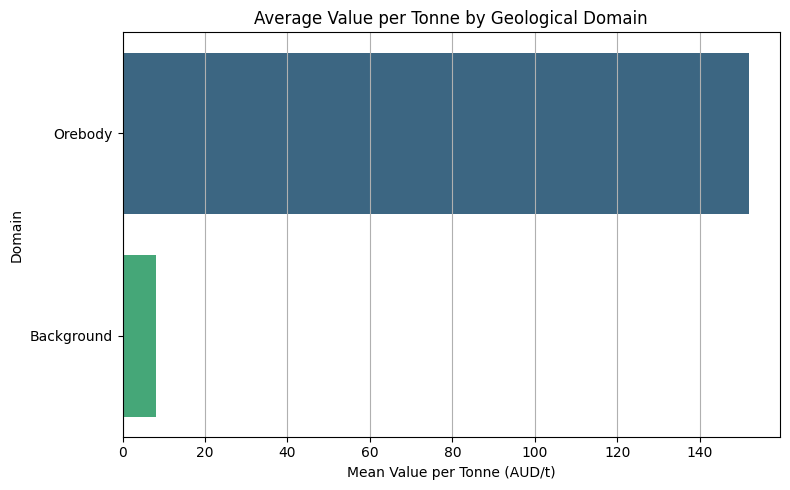

In [93]:
# ======================================================================
# 📦 6.3: BAR CHART - DOMAIN ECONOMIC COMPARISON ###
# ======================================================================

# Ensure 'domain_summary' exists, otherwise recompute it
if 'domain_summary' not in globals():
	domain_summary = block_model_df.groupby('domain').agg({
		'value_per_tonne': ['mean', 'std', 'min', 'max'],
		'Au_grade': ['mean', 'std'],
		'Cu_grade': ['mean', 'std'],
		'class': lambda x: (x == 'Ore').sum(),  # Count of ore blocks
	})

	domain_summary.columns = ['_'.join(col).strip() for col in domain_summary.columns.values]
	domain_summary.rename(columns={'class_<lambda>': 'ore_block_count'}, inplace=True)
	domain_summary['total_blocks'] = block_model_df.groupby('domain').size()
	domain_summary['ore_percentage'] = (
		100 * domain_summary['ore_block_count'] / domain_summary['total_blocks']
	)
	domain_summary = domain_summary.round(2)
	domain_summary = domain_summary.sort_values('value_per_tonne_mean', ascending=False)

# Prepare bar chart
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
	data=domain_summary.reset_index(),
	x='value_per_tonne_mean',
	y='domain',
	palette='viridis',
	ax=ax
)
ax.set_xlabel("Mean Value per Tonne (AUD/t)")
ax.set_ylabel("Domain")
ax.set_title("Average Value per Tonne by Geological Domain")
ax.grid(axis='x')

plt.tight_layout()
plt.show()


### 🖼️ **Step 6.4: Domain-Based Interactive Viewer**
An enhanced slice viewer that lets you filter visualisations by geological domain.

---

Features:
* Choose any numerical or categorical property to visualise
* Filter to a specific domain (e.g. Core, Orebody) or view All
* Slider to select Z-level slice
* Consistent with Step 3.3’s visual style and colour scaling

---

🔍 Use this to:
* Inspect how value, grade, or lithology varies within each domain
* Cross-check model realism and domain continuity
* Complement the domain summary and bar chart with spatial context
---

In [94]:
# ======================================================================
# 📦 STEP 6.4: DOMAIN-BASED INTERACTIVE VIEWER (ISOLATED VERSION)
# ======================================================================

# --- Define isolated widgets ---
property_dropdown_64 = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z', 'domain', 'block_id']],
	value='value_per_tonne',
	description='Property:'
)

domain_dropdown_64 = widgets.Dropdown(
	options=['All'] + list(domain_definitions.keys()) + ['Background'],
	value='All',
	description='Domain:'
)

domain_controls_64 = widgets.HBox([property_dropdown_64, domain_dropdown_64])
domain_output_64 = widgets.Output()

# --- Domain-specific callback ---
def domain_viewer_callback_64(slice_axis, slice_value, slice_thickness, df, property_name, **kwargs):
	with domain_output_64:
		clear_output(wait=True)

		selected = domain_dropdown_64.value
		filtered_df = df if selected == "All" else df[df["domain"] == selected]

		plot_interactive_slice(
			slice_axis=slice_axis,
			slice_value=slice_value,
			slice_thickness=slice_thickness,
			df=filtered_df,
			property_name=property_name
		)

# --- Viewer trigger ---
def launch_domain_viewer_64(*args):
	with domain_output_64:
		clear_output(wait=True)

		make_axis_slider(
			df=block_model_df,
			axis="z",
			label="Z-Level Slice",
			callback_fn=domain_viewer_callback_64,
			additional_args={
				"df": block_model_df,
				"property_name": property_dropdown_64.value
			},
			slice_thickness=model_dimensions["block_size"][2]
		)

# --- Attach dropdown change events ---
property_dropdown_64.observe(launch_domain_viewer_64, names='value')
domain_dropdown_64.observe(launch_domain_viewer_64, names='value')

# --- Display everything once ---
display(domain_controls_64)
launch_domain_viewer_64()
display(domain_output_64)

Output()

### 📊 **6.5: Domain Summary Statistics**

Generate descriptive statistics for each geological domain across key attributes.

---

✅ Current outputs include:
- **Grouped by:** `domain`
- **Descriptive stats** for:
	- `Au_grade`, `Cu_grade`
	- `density`
	- `value_per_tonne`
- Metrics: **mean, std, min, max** (from `pandas.DataFrame.describe()`)

📌 *This can be extended later to include:*
- Volume-weighted averages using `density × block volume`
- Filtering by domain type, ore class, or cut-off thresholds
- Export to CSV, Excel, or reporting dashboards


In [95]:
# ======================================================================
# 📦 STEP 6.5: DOMAIN SUMMARY STATISTICS ###
# ======================================================================

# --- Set pandas display option (optional) ---
pd.set_option('display.max_rows', None)  # Show all rows in notebook output

# --- Compute descriptive stats grouped by domain ---
domain_summary = block_model_df.groupby("domain")[
	['Au_grade', 'Cu_grade', 'density', 'value_per_tonne']
].describe().round(2)

# --- Display the summary table ---
display(domain_summary)


Au_grade                                          Cu_grade        \
              count  mean   std   min   25%  50%   75%   max    count  mean   
domain                                                                        
Background  34425.0  0.10  0.02  0.05  0.08  0.1  0.11  0.20  34425.0  0.03   
Orebody     50012.0  1.83  0.82  0.10  1.42  1.9  2.26  5.55  50012.0  0.60   

            ... density       value_per_tonne                                \
            ...     75%   max           count    mean    std    min     25%   
domain      ...                                                               
Background  ...    2.79  2.94         34425.0    8.19   1.35   4.96    7.21   
Orebody     ...    2.84  2.94         50012.0  151.88  62.18  10.56  132.12   

                                    
               50%     75%     max  
domain                              
Background    8.14    8.95   14.35  
Orebody     162.96  183.95  409.83  

[2 rows x 32 columns]

### 🧾 **Step 7: Compute Mass, Resources, and Visualisation**
Now that each block has spatial, geological, and economic attributes, we can simulate core mining outputs — from tonnage and grade reporting to 3D visualisation.

---

#### ⚙️ **What’s Included:**
* 📦 Volume and mass calculations per block
* 💰 Resource estimation by domain and classification
* 🧱 SMU adjustment to reflect realistic selectivity
* 📊 Descriptive stats, distributions, and correlations
* 🔍 3D visualisation (point cloud, voxel grid, slicing)
* 🛠️ Drillhole assay viewer for downhole grade trends

These tools provide essential outputs for resource evaluation, Mine-to-Mill analysis, and technical reporting — while also supporting QA/QC and geometallurgical insight.

---

### 🧮 **Step 7.1: Volume and Tonnage Calculations**

Each block has a fixed geometric volume based on its dimensions (X × Y × Z). Combined with block-specific density values, we calculate:

- 📏 **Volume** in cubic metres (`volume_m3`)
- ⚖️ **Mass** in tonnes (`tonnes`)

---

We then summarise total **volume and tonnage** by:

- Geological **domain** (e.g. Core, Orebody)
- Economic **classification** (`Ore` vs `Waste`)

---

✅ Final outputs include:
- Per-category breakdown of total tonnage and volume
- Total in-situ tonnes across the block model
- Sanity check comparing modelled vs theoretical maximum volume (based on grid)


In [96]:
# ======================================================================
# 📦 STEP 7.1: VOLUME & TONNAGE CALCULATIONS ###
# ======================================================================

import IPython.display as disp

# --- Calculate block volume and mass ---
block_volume = (
	model_dimensions["block_size"][0] *
	model_dimensions["block_size"][1] *
	model_dimensions["block_size"][2]
)

# Assign volume and mass to each block
block_model_df["volume_m3"] = block_volume
block_model_df["tonnes"] = block_model_df["volume_m3"] * block_model_df["density"]

# --- Aggregate tonnage and volume by domain and classification ---
tonnage_summary = block_model_df.groupby(["domain", "class"])[
	["volume_m3", "tonnes"]
].sum().round(2)

# --- Display the summary ---
disp.display(tonnage_summary)

# --- Quick sanity check: total volume and tonnes ---
total_volume = block_model_df["volume_m3"].sum()
total_tonnes = block_model_df["tonnes"].sum()

print(f"✅ Total block volume: {total_volume:,.0f} m³")
print(f"✅ Total block mass: {total_tonnes:,.0f} tonnes")


# Max possible volume based on model grid
nx = int(model_dimensions["extent"][0] / model_dimensions["block_size"][0])
ny = int(model_dimensions["extent"][1] / model_dimensions["block_size"][1])
nz = int(model_dimensions["extent"][2] / model_dimensions["block_size"][2])
total_blocks = nx * ny * nz
theoretical_volume = total_blocks * block_volume

print(f"🔍 Theoretical max volume: {theoretical_volume:,.0f} m³")
print(f"📦 Actual model volume: {total_volume:,.0f} m³ ({(total_volume / theoretical_volume) * 100:.1f}%)")


volume_m3        tonnes
domain     class                         
Background Waste  215156250  5.876869e+08
Orebody    Ore    195843750  5.447876e+08
           Waste  116731250  3.239196e+08

✅ Total block volume: 527,731,250 m³
✅ Total block mass: 1,456,394,067 tonnes
🔍 Theoretical max volume: 558,900,000 m³
📦 Actual model volume: 527,731,250 m³ (94.4%)


### 💰 **Step 7.2: Resource Estimation by Domain**

Estimate contained metal by combining **grade** and **tonnage** for each block, grouped by geological domain and Ore/Waste class.

---

📐 Formula:
$$
\text{Contained Metal} = \sum(\text{Grade} \times \text{Tonnes})
$$

---

✅ Features:
- Aggregates **tonnes**, **average grade**, and **contained metal**
- Applies unit-aware conversion:
	- Gold (g/t × tonnes → oz)
	- Copper (% × tonnes → tonnes)
- Outputs results by `Domain` and `Class` for each `Mineral`


In [97]:
# ======================================================================
# 📦 7.2: RESOURCE ESTIMATION BY DOMAIN ###
# ======================================================================

resource_table = []

# --- Loop through each mineral and domain/class combination ---
for mineral in minerals:
	grade_col = f"{mineral}_grade"

	for (domain, ore_class), group in block_model_df.groupby(["domain", "class"]):
		tonnes = group["tonnes"].sum()
		avg_grade = group[grade_col].mean()

		# --- Convert grade × tonnes into contained metal ---
		unit = economic_data[mineral]["unit"]

		if unit == "oz":
			# g/t × tonnes ÷ 31.1035 = ounces
			contained = (group[grade_col] * group["tonnes"] / 31.1035).sum()
		elif unit == "%":
			# % × tonnes ÷ 100 = tonnes of metal
			contained = (group[grade_col] * group["tonnes"] / 100).sum()
		else:
			contained = np.nan  # Unknown unit

		resource_table.append({
			"Mineral": mineral,
			"Domain": domain,
			"Class": ore_class,
			"Tonnes": round(tonnes, 2),
			"Avg Grade": round(avg_grade, 3),
			"Contained": round(contained, 2)
		})

# --- Convert to DataFrame and display ---
resource_df = pd.DataFrame(resource_table)
disp.display(resource_df)


,Mineral,Domain,Class,Tonnes,Avg Grade,Contained
0,Au,Background,Waste,5.876869e+08,0.096,1823039.60
1,Au,Orebody,Ore,5.447876e+08,2.304,40346916.43
2,Au,Orebody,Waste,3.239196e+08,1.034,10773636.80
3,Cu,Background,Waste,5.876869e+08,0.034,199032.40
4,Cu,Orebody,Ore,5.447876e+08,0.716,3902287.96
5,Cu,Orebody,Waste,3.239196e+08,0.397,1287157.16


### 🆔 **Step 7.3: Assign Block IDSs**

Assign a unique identifier to each block using its spatial coordinates (`x`, `y`, `z`). This allows consistent referencing across simulations, exports, and transformations.
---
✅ Why assign Block IDs?
 - Track blocks across processing stages
 - Export cleanly to CSV, GIS, or scheduling tools
 - Use as keys in sampling or drilling logic

🧠 Format: `x_y_z` — based on each block’s centre coordinates

In [98]:
# ======================================================================
# 📦 STEP 7.3: ASSIGN BLOCK IDs ###
# ======================================================================

# --- Create unique block IDs using X, Y, Z centre coordinates ---
block_model_df["block_id"] = (
	block_model_df["x"].astype(int).astype(str) + "_" +
	block_model_df["y"].astype(int).astype(str) + "_" +
	block_model_df["z"].astype(int).astype(str)
)

# --- Preview first few blocks ---
block_model_df[["block_id", "x", "y", "z"]].head(3)


,block_id,x,y,z
0,1552_667_-665,1552.5,667.5,-665.0
1,1577_667_-665,1577.5,667.5,-665.0
2,1602_667_-665,1602.5,667.5,-665.0


### ⛏️ **Step 7.4: SMU Adjustment**

In real mining operations, fine-scale selectivity is limited by equipment size (e.g. excavator bucket, blast pattern, or dig unit). The **Selective Mining Unit (SMU)** defines the smallest practical volume that can be selectively mined, influencing ore control, dilution, and misclassification.

---

This step simulates SMU effects by:
* 🧮 Applying a 3D uniform filter (3×3×1 window) using `scipy.ndimage` to the value_per_tonne array
* 🧊 Smoothing occurs across neighbouring blocks in the same bench to simulate horizontal mixing
* 🎯 Reclassifying blocks using the smoothed value with the original economic cutoff (`value_cutoff`)
* 💾 Storing results in:
	* `value_smu`: the smoothed economic value
	* `class_smu`: new classification (`Ore` or `Waste`)

---

#### 🧠 Why It Matters:
This adjustment introduces realistic effects of:
* **Dilution** – blending of ore and waste within an SMU
* **Loss of granularity** – due to equipment size limits
* **Misclassification** – marginal blocks can flip class due to local averaging

These effects are common in production and reconciliation, and this step creates a more realistic foundation for downstream scheduling, optimisation, or resource reporting.

*Note: No smoothing is applied vertically to preserve bench-wise selectivity.*

In [99]:
# ======================================================================
# 📦 STEP 7.4: SMU ADJUSTMENT — 3D SPATIAL SMOOTHING ###
# ======================================================================

from scipy.ndimage import uniform_filter

# --- Step 1: Classify blocks using raw value ---
block_model_df["class"] = np.where(
    block_model_df["value_per_tonne"] >= value_cutoff, "Ore", "Waste"
)

# --- Step 2: Build 3D grid for smoothing ---
x_vals = np.sort(block_model_df['x'].unique())
y_vals = np.sort(block_model_df['y'].unique())
z_vals = np.sort(block_model_df['z'].unique())

x_idx = {val: idx for idx, val in enumerate(x_vals)}
y_idx = {val: idx for idx, val in enumerate(y_vals)}
z_idx = {val: idx for idx, val in enumerate(z_vals)}

shape = (len(x_vals), len(y_vals), len(z_vals))
value_grid = np.full(shape, np.nan)

for _, row in block_model_df.iterrows():
    i = x_idx[row['x']]
    j = y_idx[row['y']]
    k = z_idx[row['z']]
    value_grid[i, j, k] = row['value_per_tonne']

# --- Step 3: Apply spatial smoothing ---
nan_mask = np.isnan(value_grid)
value_grid_filled = np.nan_to_num(value_grid, nan=0.0)

smoothed_grid = uniform_filter(value_grid_filled, size=(3, 3, 1))
smoothed_grid[nan_mask] = np.nan  # Restore NaNs

# --- Step 4: Map smoothed values back to DataFrame ---
smoothed_lookup = {
    (x_vals[i], y_vals[j], z_vals[k]): smoothed_grid[i, j, k]
    for i in range(len(x_vals))
    for j in range(len(y_vals))
    for k in range(len(z_vals))
}

block_model_df["value_smu"] = block_model_df.apply(
    lambda row: smoothed_lookup.get((row["x"], row["y"], row["z"]), np.nan),
    axis=1
)

# --- Step 5: Reclassify based on smoothed value ---
block_model_df["class_smu"] = np.where(
    block_model_df["value_smu"] >= value_cutoff, "Ore", "Waste"
)

print("✅ SMU adjustment completed using 3D spatial smoothing.")


✅ SMU adjustment completed using 3D spatial smoothing.


In [100]:
# ======================================================================
# 🧪 BLOCK MODEL DIAGNOSTIC SUMMARY (Notebook Version)
# ======================================================================

print("📊 BLOCK MODEL DIAGNOSTICS (Notebook Version)\n")

print(f"🔢 Total blocks generated: {len(block_model_df)}")
print(f"🧱 Unique blocks (x, y, z): {block_model_df[['x', 'y', 'z']].drop_duplicates().shape[0]}")
print(f"🕳️ Skipped due to domain: {len(block_model_df[block_model_df['zone_code'] == 0])}")
print(f"✅ SMU Value present? {'value_smu' in block_model_df.columns}")
if 'value_smu' in block_model_df.columns:
    print(f"🔍 SMU classification:\n{block_model_df['class_smu'].value_counts(dropna=False)}")

print("\n📦 Material Class Breakdown:")
print(block_model_df["class"].value_counts(dropna=False))

print("\n🌋 Oxidation Zone Tonnes:")
print(block_model_df.groupby("oxidation_zone")["tonnes"].sum().round(0))

print("\n🏷️ Zone Summary:")
print(block_model_df["concentric_zone"].value_counts(dropna=False))

# print("\n🔢 Unique Lithologies:")
# print(block_model_df["lith_code"].value_counts(dropna=False))

print("\n🪨 Fault Zone Summary:")
if "fault_zone_category" in block_model_df.columns:
    print(block_model_df["fault_zone_category"].value_counts(dropna=False))
else:
    print("⚠️ Fault zones not enabled.")


📊 BLOCK MODEL DIAGNOSTICS (Notebook Version)

🔢 Total blocks generated: 84437
🧱 Unique blocks (x, y, z): 84437
🕳️ Skipped due to domain: 54553
✅ SMU Value present? True
🔍 SMU classification:
class_smu
Waste    58429
Ore      26008
Name: count, dtype: int64

📦 Material Class Breakdown:
class
Waste    53102
Ore      31335
Name: count, dtype: int64

🌋 Oxidation Zone Tonnes:
oxidation_zone
Fresh         1.365021e+09
Oxide         5.783343e+07
Transition    3.353982e+07
Name: tonnes, dtype: float64

🏷️ Zone Summary:
concentric_zone
Background    54553
Inner         10635
Core           9665
Mid            6503
Outer          2926
Deep Core       155
Name: count, dtype: int64

🪨 Fault Zone Summary:
fault_zone_category
none    69017
halo    11219
core     4201
Name: count, dtype: int64


### 🧊 **7.5: 3D Block Model Visualisation**

This tool enables interactive 3D visualisation of the synthetic block model using PyVista, with multiple rendering styles to suit different inspection and presentation needs.

---

#### 1️⃣ Point Cloud View
* Renders each block as a small sphere at its (`x`, `y`, `z`) centre
* Lightweight and efficient, ideal for viewing spatial distributions or categorical attributes (e.g. `class`, `lithology`)
* Useful for quick scans and large block models

---

#### 2️⃣ Voxel Grid View
* Full 3D voxel rendering using ImageData
* Blocks are displayed as solid cubes with preserved dimensions
* Opacity mapping allows for transparency-based insight into internal structures
* Ideal for visualising continuous properties (e.g. `Au_grade`, `value_per_tonne`)

---

#### 3️⃣ Voxel Slice View
* Renders orthogonal cross-sections through X, Y, and Z axes
* Designed for exploring vertical and horizontal transitions in grade, value, or classification
* Controlled with interactive sliders

---

#### ✅ Viewer Features
* **Dropdown** to choose the property to visualise
* **Radio buttons** to switch between point cloud, full grid, or slice view
* **Opacity** settings to reveal internal structure in voxel grid mode
* **Sliders** to adjust X, Y, Z slice position dynamically

📌 Useful for presentations, spatial QA/QC, and domain verification

---

In [101]:
# ======================================================================
# 📦 STEP 7.5: 3D BLOCK MODEL VISUALISATION ###
# ======================================================================

pv.set_jupyter_backend('trame')

# --- Compute global colour scale range (shared by both plots) ---
def get_color_range(property_col):
	return (
		block_model_df[property_col].min(),
		block_model_df[property_col].max()
	)

###--- POINT CLOUD RENDERING ---###
def plot_voxels_point_cloud(property_col="value_per_tonne"):
	"""Render block model as 3D point cloud (scatter spheres)"""
	if property_col not in block_model_df.columns:
		print(f"⚠️ Property '{property_col}' not found.")
		return

	coords = block_model_df[["x", "y", "z"]].values
	values = block_model_df[property_col].values
	cloud = pv.PolyData(coords)
	cloud[property_col] = values

	pv.plot(
		cloud,
		scalars=property_col,
		point_size=5,
		render_points_as_spheres=True,
		cmap=property_colormaps.get(property_col, "plasma"),
		clim=get_color_range(property_col),
		show_scalar_bar=True,
		notebook=True,
		jupyter_backend=None
	)

###--- VOXEL GRID OR SLICE ---###    
def plot_voxel_grid(property_col="value_per_tonne", use_slice=False, opacity_map="linear",
					x_val=None, y_val=None, z_val=None):
	"""Render block model as voxel grid or orthogonal slice using ImageData"""
	if property_col not in block_model_df.columns:
		print(f"⚠️ Property '{property_col}' not found.")
		return
	
	# Geometry setup
	dx, dy, dz = model_dimensions["block_size"]
	x0, y0, z0 = model_dimensions["origin"]
	nx = int(model_dimensions["extent"][0] / dx)
	ny = int(model_dimensions["extent"][1] / dy)
	nz = int(model_dimensions["extent"][2] / dz)

	# Build voxel grid
	grid = pv.ImageData(
		dimensions=(nx + 1, ny + 1, nz + 1),
		spacing=(dx, dy, dz),
		origin=(x0, y0, z0)
	)

	# Create empty 3D array filled with NaNs
	data_3d = np.full((nz, ny, nx), np.nan)

	# Map (x, y, z) coordinates to voxel indices
	ix = ((block_model_df["x"] - x0) / dx).round().astype(int)
	iy = ((block_model_df["y"] - y0) / dy).round().astype(int)
	iz = ((block_model_df["z"] - z0) / dz).round().astype(int)

	# Safety check to avoid indexing errors
	valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny) & (iz >= 0) & (iz < nz)

	# Assign property values
	data_3d[iz[valid], iy[valid], ix[valid]] = block_model_df.loc[valid, property_col].values

	grid.cell_data[property_col] = data_3d.flatten(order="F")

	# Plot either full voxel volume or slice
	if use_slice:
		x_val = x_val if x_val is not None else extent[0] / 2
		y_val = y_val if y_val is not None else extent[1] / 2
		z_val = z_val if z_val is not None else extent[2] / 2

		sliced = grid.slice_orthogonal(x=x_val, y=y_val, z=z_val)
		pv.plot(
			sliced,
			scalars=property_col,
			cmap=property_colormaps.get(property_col, "plasma"),
			clim=get_color_range(property_col),
			show_scalar_bar=True,
			notebook=True,
			jupyter_backend=None
		)
	else:
		pv.plot(
			grid,
			scalars=property_col,
			cmap=property_colormaps.get(property_col, "plasma"),
			opacity=opacity_map,
			clim=get_color_range(property_col),
			show_scalar_bar=True,
			notebook=True,
			jupyter_backend=None
		)

###--- SLICE COORDINATE SLIDERS ---###
x_slider = widgets.IntSlider(
	description="X Slice:", min=0, max=model_dimensions['extent'][0], step=25, value=500
	)
y_slider = widgets.IntSlider(
	description="Y Slice:", min=0, max=model_dimensions['extent'][1], step=25, value=350
	)
z_slider = widgets.IntSlider(
	description="Z Slice:", min=0, max=model_dimensions['extent'][2], step=10, value=165
	)

###--- UI CONTROLS ---###
voxel_property_dropdown = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z', 'block_id', 'currency']],
	value="value_per_tonne",
	description="Property:"
)

view_type_radio = widgets.RadioButtons(
	options=["Point Cloud", "Voxel Grid", "Voxel Slice"],
	value="Voxel Grid",
	description="View Type:"
)

opacity_dropdown = widgets.Dropdown(
	options=["linear", "linear_r", "sigmoid", "sigmoid_5", "sigmoid_10", "geom", "geom_r"],
	value="linear",
	description="Opacity:"
)

###--- VIEW SELECTION HANDLER ---###
def interactive_voxel_plot(property_col, view_type, opacity, x_val, y_val, z_val):
	if view_type == "Point Cloud":
		plot_voxels_point_cloud(property_col)
	elif view_type == "Voxel Grid":
		plot_voxel_grid(property_col=property_col, use_slice=False, opacity_map=opacity)
	elif view_type == "Voxel Slice":
		plot_voxel_grid(property_col=property_col, use_slice=True, opacity_map=opacity,
						x_val=x_val, y_val=y_val, z_val=z_val)
	else:
		print("Unknown view type selected.")

###--- BIND INTERACTORS ---###
ui = widgets.VBox([
	voxel_property_dropdown,
	view_type_radio,
	opacity_dropdown,
	x_slider,
	y_slider,
	z_slider
])

interactive_out = widgets.interactive_output(
	interactive_voxel_plot,
	{
		"property_col": voxel_property_dropdown,
		"view_type": view_type_radio,
		"opacity": opacity_dropdown,
		"x_val": x_slider,
		"y_val": y_slider,
		"z_val": z_slider
	}
)

display(ui, interactive_out)



Output()

### 📊 **7.6: Distribution and Correlation Checks**

Perform exploratory data analysis to validate the statistical properties of your block model.

---

#### 📈 What’s Included:
- **Histograms + KDE curves** for key numeric properties (e.g. grades, value, UCS)
- **Correlation matrix heatmap** to explore inter-parameter relationships

These checks are especially useful after applying dependency logic (e.g. UCS → RMR) to ensure that realistic trends and variability are preserved.

Plotting Histograms:   0%|          | 0/9 [00:00<?, ?it/s]

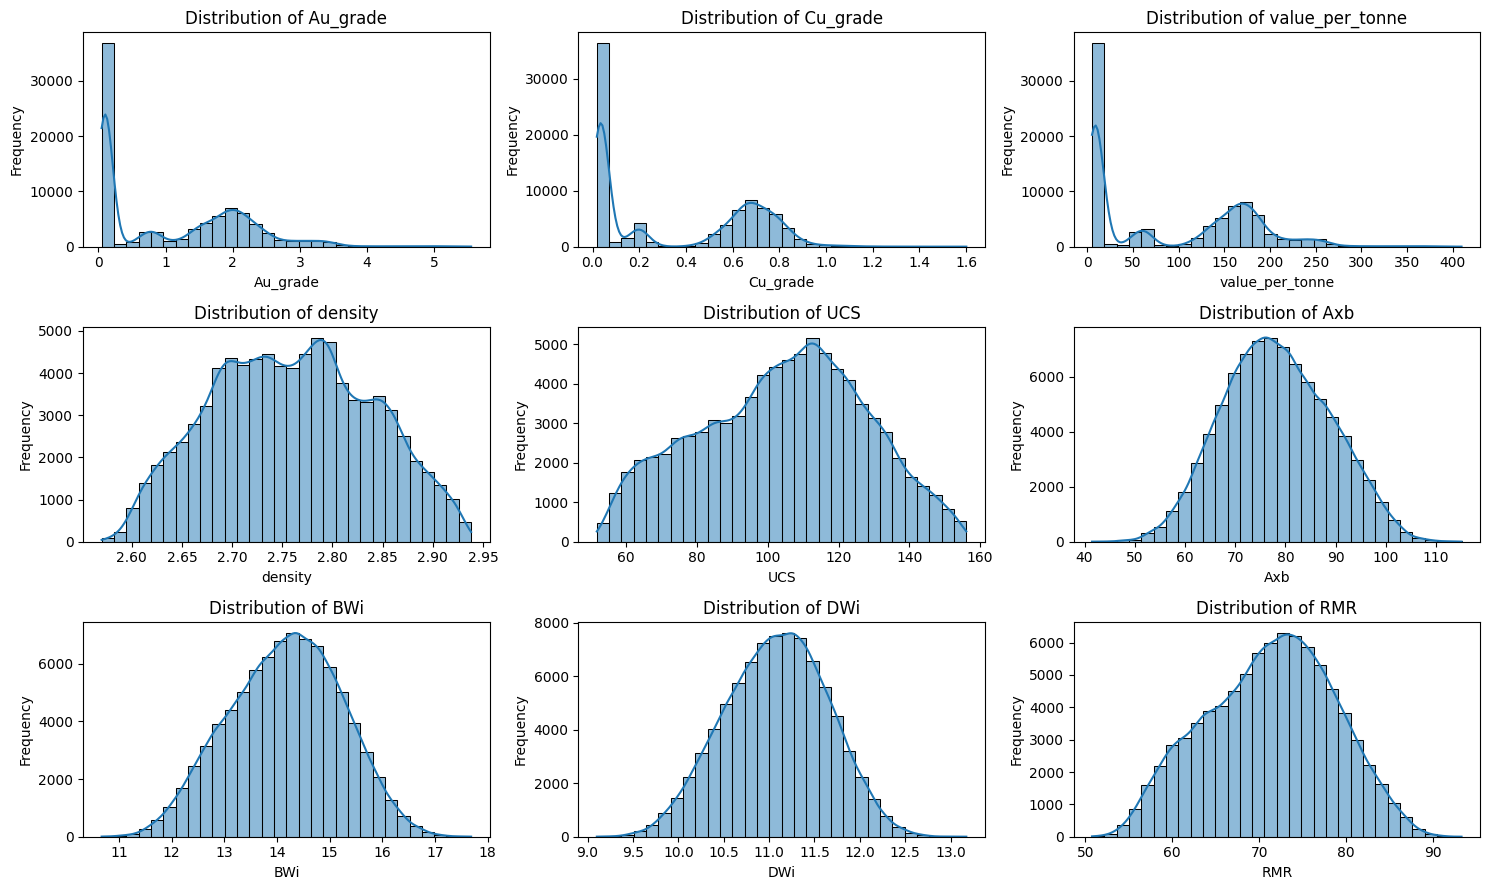

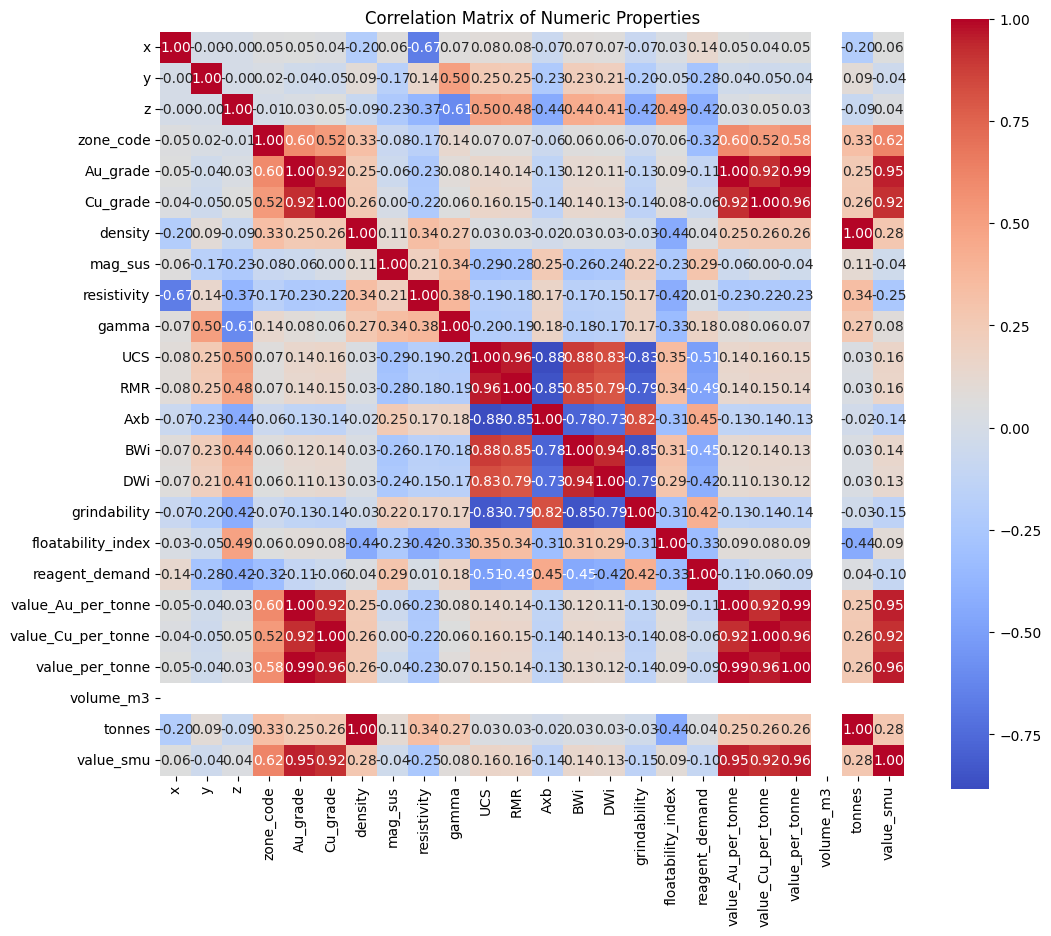

In [102]:
# ======================================================================
# 📦 STEP 7.6: DISTRIBUTON AND CORRELATION CHECKS ###
# ======================================================================

# --- Histogram Plots ---
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
props_to_plot = ['Au_grade', 'Cu_grade', 'value_per_tonne', 'density', 'UCS', 'Axb', 'BWi', 'DWi', 'RMR']

for i, col in tqdm(list(enumerate(props_to_plot)), desc="Plotting Histograms"):
	sns.histplot(block_model_df[col], kde=True, bins=30, ax=axes[i // 3, i % 3])
	axes[i // 3, i % 3].set_title(f"Distribution of {col}")
	axes[i // 3, i % 3].set_xlabel(col)
	axes[i // 3, i % 3].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# --- Correlation Matrix ---
numeric_df = block_model_df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix of Numeric Properties")
plt.show()


### 🛠️ **7.7: Interactive Drillhole Assay Viewer**

Simulate vertical drillhole assays through the block model and explore how metal grades change with depth.

---

#### 🎯 **Key Features:**
* Randomly sampled drillholes from (x, y) locations
* Select any drillhole by ID
* Choose two metals to compare side-by-side
* Interactive depth plot:
	* X-axis: grade
	* Y-axis: depth (inverted to simulate downhole view)
* Auto-adjusts dropdowns to prevent duplicate metal selection

---

#### 🧪 **Use Cases:**
* Validate vertical grade continuity
* Compare co-enrichment (e.g., Au vs Cu)
* Identify vertical zonation patterns or enrichment zones

---

#### ✅ **Useful for visual QA/QC and checking realism of simulated grade distributions.**

Let me know if you want to enhance this further by:
* Adding class or domain colour bands
* Showing SMU-adjusted values alongside raw ones
* Exporting selected drillhole data to CSV

---

In [103]:
# ======================================================================
# 📦 STEP 7.7: INTERACTIVE DRILLHOLE ASSAY VIEWER ###
# ======================================================================
import plotly.graph_objects as go

# --- Drillhole Generation Parameters ---
n_holes = drillhole_parameters["n_holes"]
np.random.seed(drillhole_parameters["random_seed"])

# --- Get unique X and Y coordinates ---
x_values = sorted(block_model_df["x"].unique())
y_values = sorted(block_model_df["y"].unique())

# --- Randomly sample drillhole positions ---
hole_coords = np.random.choice(len(x_values) * len(y_values), n_holes, replace=False)
sampled_holes = []

for idx in hole_coords:
	xi = x_values[idx % len(x_values)]
	yi = y_values[idx // len(x_values)]

	hole_df = block_model_df[
		(block_model_df["x"] == xi) & (block_model_df["y"] == yi)
	].sort_values("z")

	hole_df = hole_df.copy()
	hole_df["hole_id"] = f"H{idx}"
	sampled_holes.append(hole_df)

# --- Combine into full drillhole DataFrame ---
drillhole_df = pd.concat(sampled_holes, ignore_index=True)

# --- Dropdown Widgets ---
available_metals = list(minerals.keys())
available_holes = drillhole_df['hole_id'].unique().tolist()

hole_dropdown = widgets.Dropdown(
	options=available_holes,
	value=available_holes[0],
	description='Drillhole:',
	layout=widgets.Layout(width='50%')
)

metal1_dropdown = widgets.Dropdown(
	options=available_metals,
	value=available_metals[0],
	description='Metal 1:',
	layout=widgets.Layout(width='50%')
)

metal2_dropdown = widgets.Dropdown(
	options=[m for m in available_metals if m != metal1_dropdown.value],
	value=[m for m in available_metals if m != metal1_dropdown.value][0],
	description='Metal 2:',
	layout=widgets.Layout(width='50%')
)

# --- Auto-update Metal 2 when Metal 1 changes ---
def update_metal2_options(*args):
	metal2_dropdown.options = [m for m in available_metals if m != metal1_dropdown.value]
	if metal2_dropdown.value == metal1_dropdown.value:
		metal2_dropdown.value = metal2_dropdown.options[0]

metal1_dropdown.observe(update_metal2_options, names='value')

# --- Plot Function ---
def plot_dual_metal_drillhole(hole_id, metal1, metal2):
	df = drillhole_df[drillhole_df['hole_id'] == hole_id]
	if df.empty:
		print(f"⚠️ No data found for drillhole: {hole_id}")
		return

	fig = go.Figure()

	for metal in [metal1, metal2]:
		grade_col = f"{metal}_grade"
		if grade_col in df.columns:
			fig.add_trace(go.Scatter(
				x=df[grade_col],
				y=df['z'],
				mode='lines+markers',
				name=f"{metal} Grade",
				line=dict(shape='hv'),
				# reverse the y-axis for depth
			))

	fig.update_yaxes(title='Depth (m)')
	fig.update_xaxes(title='Grade')
	fig.update_layout(
		title=f"Simulated Drillhole Assay – {hole_id}",
		height=500
	)
	fig.show()

# --- Interactive Viewer ---
widgets.interact(
	plot_dual_metal_drillhole,
	hole_id=hole_dropdown,
	metal1=metal1_dropdown,
	metal2=metal2_dropdown
)


interactive(children=(Dropdown(description='Drillhole:', layout=Layout(width='50%'), options=('H264', 'H171', …

<function __main__.plot_dual_metal_drillhole(hole_id, metal1, metal2)>

In [104]:
block_model_df.head()

,x,y,z,zone_code,concentric_zone,Au_grade,Cu_grade,fault_name,fault_zone_category,density,...,value_Au_per_tonne,value_Cu_per_tonne,value_per_tonne,class,domain,volume_m3,tonnes,block_id,value_smu,class_smu
0,1552.5,667.5,-665.0,0,Background,0.095000,0.032500,None,none,2.700000,...,5.479448,2.522090,8.001538,Waste,Background,6250,16875.000000,1552_667_-665,8.157946,Waste
1,1577.5,667.5,-665.0,0,Background,0.100572,0.032353,None,none,2.700075,...,5.800805,2.510714,8.311519,Waste,Background,6250,16875.469230,1577_667_-665,8.366334,Waste
2,1602.5,667.5,-665.0,0,Background,0.106959,0.031716,None,none,2.700556,...,6.169201,2.461249,8.630450,Waste,Background,6250,16878.472593,1602_667_-665,8.679274,Waste
3,1627.5,667.5,-665.0,0,Background,0.113733,0.030800,None,none,2.701731,...,6.559939,2.390185,8.950123,Waste,Background,6250,16885.819808,1627_667_-665,8.984247,Waste
4,1652.5,667.5,-665.0,0,Background,0.119880,0.030003,None,none,2.703780,...,6.914474,2.328346,9.242820,Waste,Background,6250,16898.626182,1652_667_-665,9.257262,Waste


### 💾 **Step 8 Export Final Block Model**

Export the full synthetic block model — with all enhancements and derived attributes — for downstream use in analysis, modelling, or reporting.

---

#### ✅ What’s Included:
* 📍 Spatial coordinates: x, y, z
* 🪙 Mineral grades: Au_grade, Cu_grade, etc.
* ⚙️ Rock properties: density, UCS, Axb, etc.
* 💰 Economic fields: value_per_tonne, class, value_smu, class_smu
* 🧱 Domain tagging: domain, Orebody, Core, etc.
* 🆔 Unique block identifiers: block_id
* 🧪 Optional drillhole assay samples

---

#### 💾 Output Formats:
- **CSV** – for spreadsheets, GIS tools, or manual inspection
- **Parquet** – fast, compressed format for large-scale workflows (e.g., Pandas, Spark)
- **JSON (line-delimited)** – ideal for APIs, web apps, and lightweight streaming

📁 Saved to: ../data/

Use these exports in your mine planning workflows, web visualisation tools, or as a seed dataset for further simulation and optimisation.

In [105]:
import os

# --- Setup export folder ---
export_path = "../data/"
filename_base = "synthetic_block_model"
os.makedirs(export_path, exist_ok=True)

# --- Define file paths ---
csv_path = os.path.join(export_path, f"{filename_base}.csv")
parquet_path = os.path.join(export_path, f"{filename_base}.parquet")
json_path = os.path.join(export_path, f"{filename_base}.json")

# --- Export block model in multiple formats ---
block_model_df.to_csv(csv_path, index=False)
block_model_df.to_parquet(parquet_path, index=False)
block_model_df.to_json(json_path, orient="records", lines=True)

# --- Optional: Export drillhole assays (if available) ---
drillhole_path = os.path.join(export_path, f"{filename_base}_drillholes.csv")
if "drillhole_df" in globals():
	drillhole_df.to_csv(drillhole_path, index=False)
	print(f"  • Drillholes: {drillhole_path}")

# --- Confirmation message ---
print("✅ Block model exported successfully:")
print(f"  • CSV:     {csv_path}")
print(f"  • Parquet: {parquet_path}")
print(f"  • JSON:    {json_path}")


  • Drillholes: ../data/synthetic_block_model_drillholes.csv
✅ Block model exported successfully:
  • CSV:     ../data/synthetic_block_model.csv
  • Parquet: ../data/synthetic_block_model.parquet
  • JSON:    ../data/synthetic_block_model.json
